In [1]:
from rqalpha.api import *
from rqalpha import run_func
import rqdatac
import numpy as np
import pandas as pd
import datetime as dt
import os

In [2]:
# 在这个方法中编写任何的初始化逻辑。context对象将会在你的算法策略的任何方法之间做传递。
def init(context):
    pass

# before_trading此函数会在每天策略交易开始前被调用，当天只会被调用一次
def before_trading(context):
    pass
        
# 你选择的证券的数据更新将会触发此段逻辑，例如日或分钟历史数据切片或者是实时数据切片更新
def handle_bar(context, bar_dict):
    # 当前日期
    cur_date = context.now.date()
    
    # 指定日期调仓
    if str(cur_date) in data.index:
        # 指定日期要买入的股票池
        stock_list = data.loc[str(cur_date)].tolist()
        # 过滤当日停牌个股
        stock_list = [code for code in stock_list if not is_suspended(code)]
        # 计算个股总得分
        score = get_total_score(stock_list, cur_date, days)
        # 买入得分小于max_score的个股
        buy_list = score[score < max_score].index.tolist()
        
        # 调仓
        # 卖出
        for code in context.portfolio.positions:
            order_target_percent(code, 0)
        # 买入
        for code in buy_list:
            order_target_percent(code, float(1/len(buy_list)))
    
    # 持仓个股
    holding_stocks = list(context.portfolio.positions)
    if holding_stocks:
        # 持仓个股总得分
        score = get_total_score(holding_stocks, cur_date, days)
        # 卖出得分大于等于max_score的个股
        sell_list = score[score >= max_score].index.tolist()
        for code in sell_list:
            order_target_percent(code, 0)
        
    # 止盈/止损
    stop_loss(context)
        
    
# after_trading函数会在每天交易结束后被调用，当天只会被调用一次
def after_trading(context):
    pass

# 止盈/止损
def stop_loss(context):
    for code in context.portfolio.positions:
        # 当前价格
        last_price = current_snapshot(code).last
        # 成本
        cost = context.portfolio.positions[code].avg_price
        # 止盈
        if last_price / cost - 1 > win_threshold:
            order_target_percent(code, 0)
        
        # 止损
        if last_price / cost - 1 < -loss_threshold:
            order_target_percent(code, 0)
        
    return


# 计算个股总得分
def get_total_score(stock_list, date, days):
    # 价格数据
    close = rqdatac.get_price(stock_list, start_date=rqdatac.get_previous_trading_date(date, days+200), end_date=date, frequency='1d', fields=['close'])
    close = pd.pivot_table(close, values='close', index='date', columns='order_book_id')
    high = rqdatac.get_price(stock_list, start_date=rqdatac.get_previous_trading_date(date, days+200), end_date=date, frequency='1d', fields=['high'])
    high = pd.pivot_table(high, values='high', index='date', columns='order_book_id')
    low = rqdatac.get_price(stock_list, start_date=rqdatac.get_previous_trading_date(date, days+200), end_date=date, frequency='1d', fields=['low'])
    low = pd.pivot_table(low, values='low', index='date', columns='order_book_id')
    
    # 计算均线
    MA5 = close.rolling(window=5).mean()
    MA20 = close.rolling(window=20).mean()
    MA30 = close.rolling(window=30).mean()
    # 计算MACD
    dif = close.apply(lambda x: cal_MACD(x)[0])
    dea = close.apply(lambda x: cal_MACD(x)[1])
    
    #1. 个股股价在前1个月内是否出现过向下突破20日均线
    con1 = ((close[-days:] < MA20[-days:]) & (close.shift(1)[-days:] > MA20.shift(1)[-days:])).sum()
    con1[con1 != 0] = 1
    #2. 个股股价在前1个月内的5日简单均线是否出现过向下突破30日简单均线
    con2 = ((MA5[-days:] < MA30[-days:]) & (MA5.shift(1)[-days:] > MA30.shift(1)[-days:])).sum()
    con2[con2 != 0] = 1
    #3. 个股前1个月是否出现过 DIF向下突破DEA（MACD由正转负）
    con3 = ((dif[-days:] < dea[-days:]) & (dif.shift(1)[-days:] > dea.shift(1)[-days:])).sum()
    con3[con3 != 0] = 1
    #4. 20日乖离率是否超过 8%
    bias20 = close.iloc[-1, :] / MA20.iloc[-1, :] - 1
    con4 = (bias20 > 0.08).astype(int)
    #5. KDJ中的K和D至少有一个大于80
    con5 = pd.Series(0, index=con1.index)
    for code in con5.index:
        k, d, j = cal_KDJ(close[code], high[code], low[code])
        if k[-1] > 80 or d[-1] > 80:
            con5[code] = 1
    # 计算总得分
    score = con1 + con2 + con3 + con4 + con5
    
    return score


# MACD
def cal_MACD(CLOSE, SHORT=12, LONG=26, M=9):
    DIF = cal_EMA(CLOSE,SHORT) - cal_EMA(CLOSE,LONG)
    DEA = cal_EMA(DIF,M)
    MACD = (DIF-DEA)*2
    
    return DIF, DEA, MACD


# KDJ
def cal_KDJ(CLOSE, HIGH, LOW, N=9, M1=3, M2=3):
    RSV = (CLOSE - cal_LLV(LOW, N)) / (cal_HHV(HIGH, N) - cal_LLV(LOW, N)) * 100
    K = cal_EMA(RSV, (M1*2-1))
    D = cal_EMA(K, (M2*2-1))
    J = K*3 - D*2
    
    return K, D, J


# EMA
def cal_EMA(S,N):
    return pd.Series(S).ewm(span=N, adjust=False).mean().values

# N日最大值
def cal_HHV(S,N):     
    return pd.Series(S).rolling(N).max().values

# N日最小值
def cal_LLV(S,N):
    return pd.Series(S).rolling(N).min().values

In [4]:
MultiOLS_XGBoost = pd.read_csv("MultiOLS_xgboost.csv",index_col = 0)
MultiOLS_rf = pd.read_csv("MultiOLS_rf.csv",index_col = 0)

In [ ]:
#读取多因子选出的股票
# MultiOLS_XGBoost = pd.read_csv("MultiOLS_xgboost.csv",index_col = 0)
MultiOLS_rf = pd.read_csv("MultiOLS_rf.csv",index_col = 0)

Factor_dfs = [MultiOLS_rf]
Factor_df_names = ['MultiOLS_rf']
#批量回测
back_test_details = pd.DataFrame()
for df,name in zip(Factor_dfs,Factor_df_names):
    print(name)
    start_date = '2015-02-15'
    end_date = '2023-08-01'
    # 初始资金
    init_cash = 1000000
    # 基准
    benchmark = '000300.XSHG'
    # 手续费(%)
    commission = 0
    min_commission = 0
    tax = 0
    # 读取持仓数据和名称
    data = df
    df_name = name
    # 改变日期格式
    data.index = pd.to_datetime(data.index.tolist())
    # 判断买入条件的天数
    days = 20
    # 得分上限
    max_score = 3
    # 止盈/止损阀值
    win_threshold = 0.20
    loss_threshold = 0.15
    # 回测
    config = {"base": {"accounts": {"STOCK": init_cash}, "start_date": start_date, "end_date": end_date, "frequency": "1d"},
              "mod": {"sys_analyser": {"plot": True, "benchmark": benchmark},
                      "sys_transaction_cost": {"stock_commission_multiplier ": commission, "tax_multiplier": tax, "cn_stock_min_commission": min_commission}},
              "extra": {"log_level": "error"}}
    result = run_func(init=init, before_trading=before_trading, handle_bar=handle_bar, after_trading=after_trading, config=config)
    #获取回测结果详细分析
    result_analysis = result['sys_analyser']
    #获取交易历史记录
    trade_records = result_analysis['trades']
    trade_records.to_csv(f"{df_name}_trade_records.csv")
    #获取portfolio
    portfolio = result_analysis['portfolio'].loc['2015-03-30':]
    benchmark = result_analysis['benchmark_portfolio'].loc['2015-03-30':]
    concat_port_ben = pd.concat([portfolio,benchmark],axis = 1)
    concat_port_ben.to_csv(f'{df_name}_portfolio_records.csv')
    #获取summray并合并进back_test_details
    summary = pd.DataFrame(result_analysis['summary']).iloc[0].to_frame().rename(columns = {0:df_name})
    back_test_details = pd.concat([back_test_details,summary],axis = 1)
back_test_details.to_csv("策略全年回测.csv")

MultiOLS_XGBoost在2015


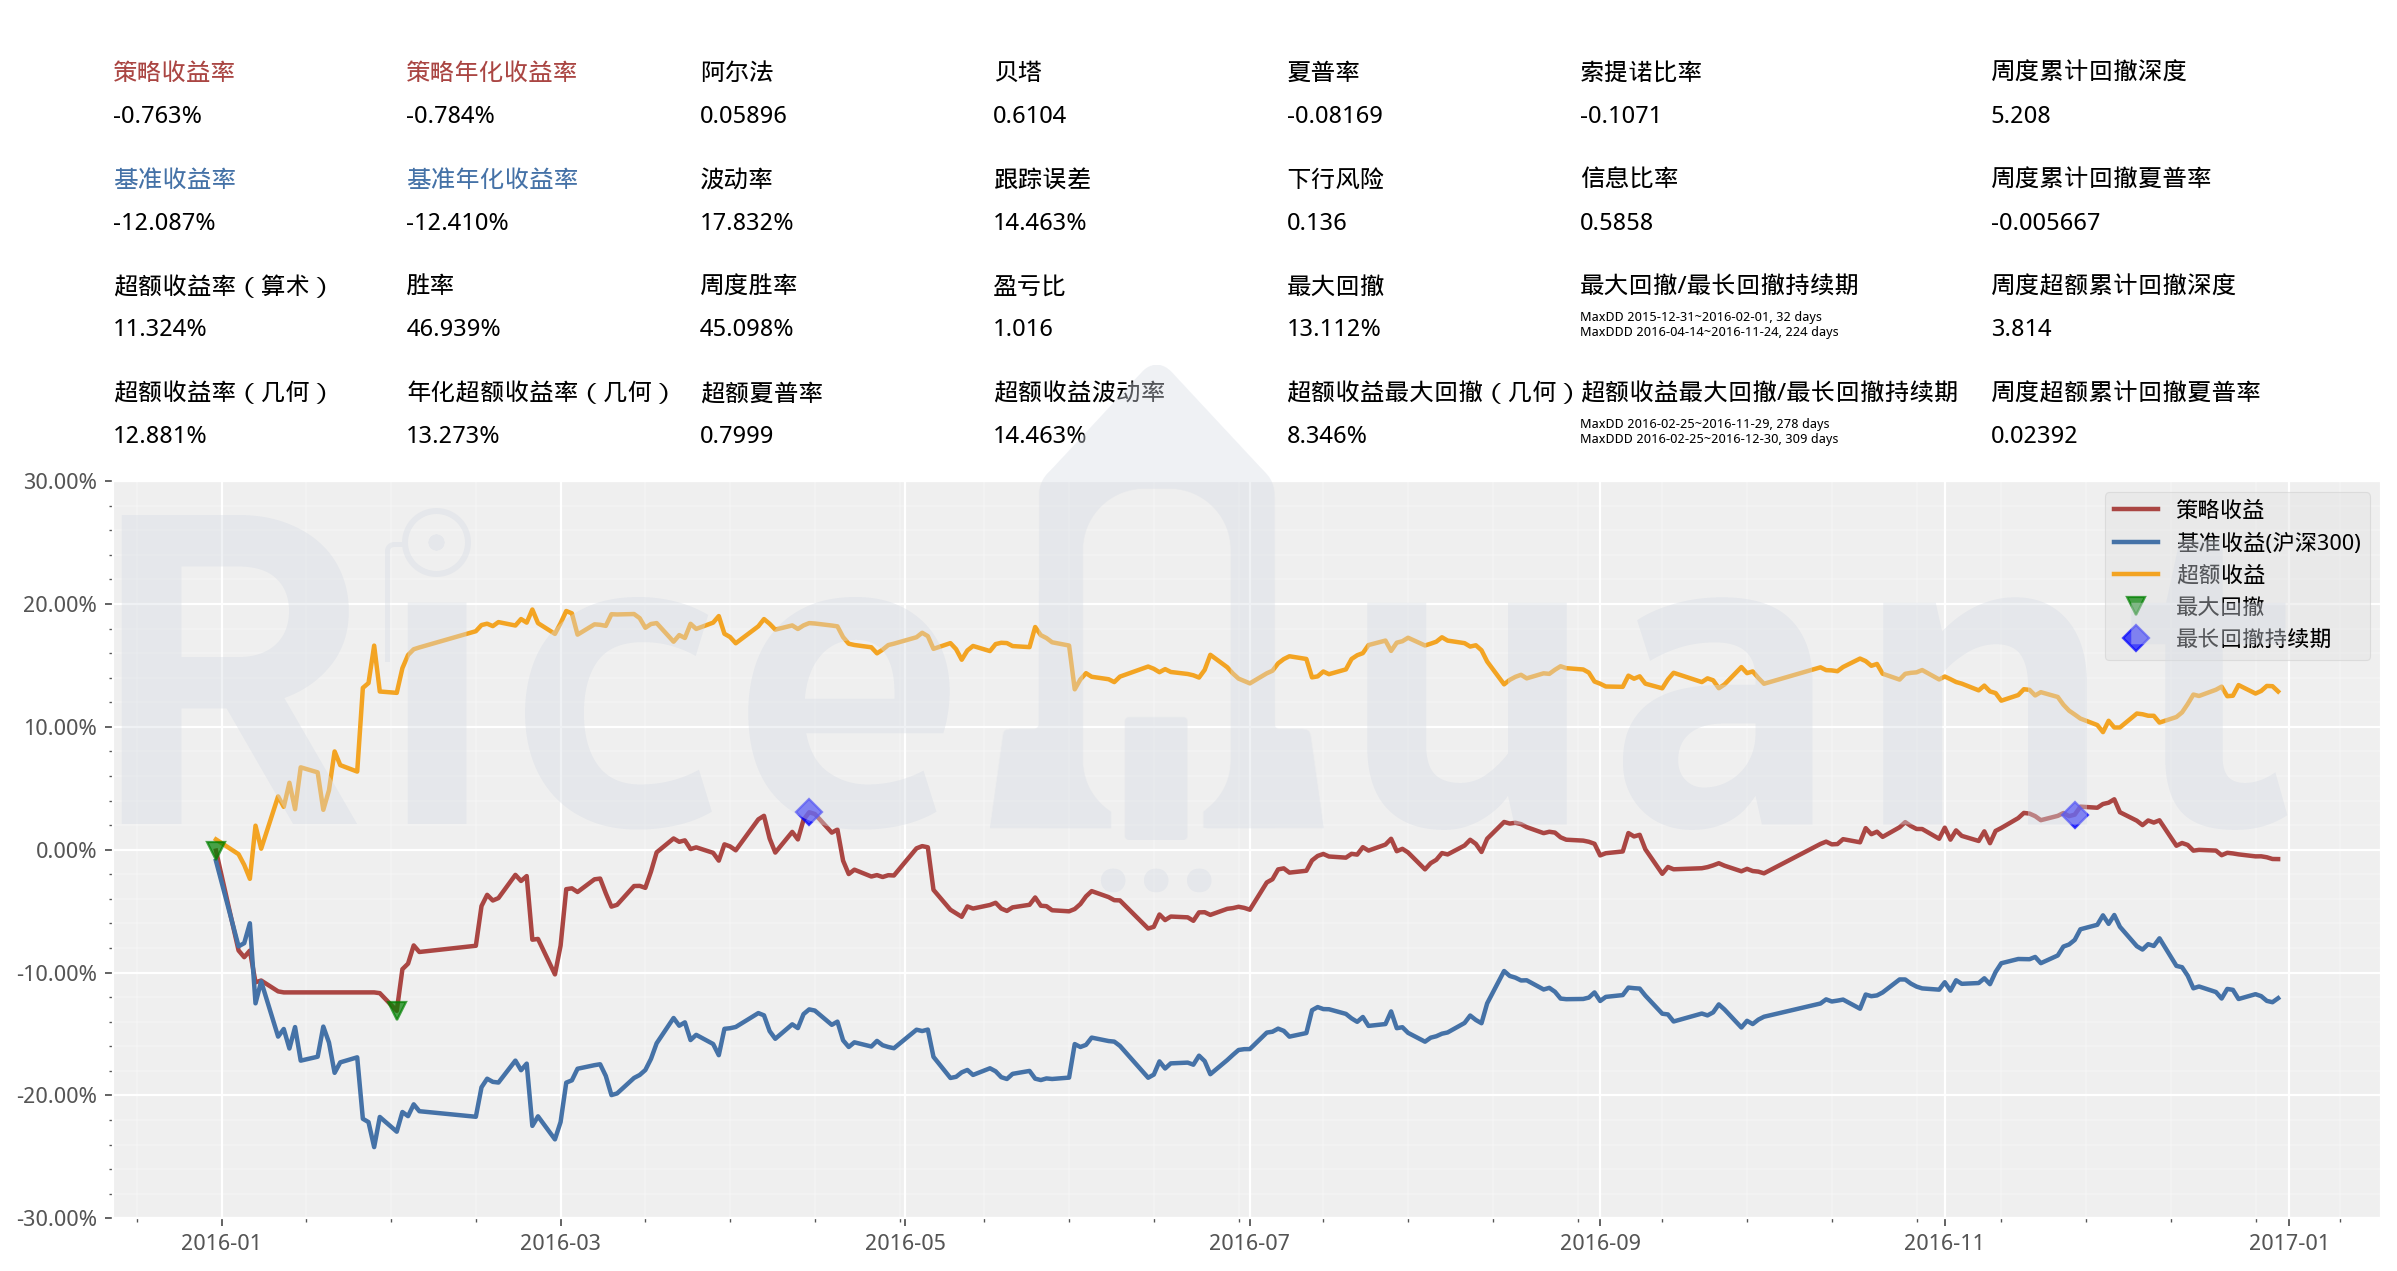

MultiOLS_XGBoost在2016


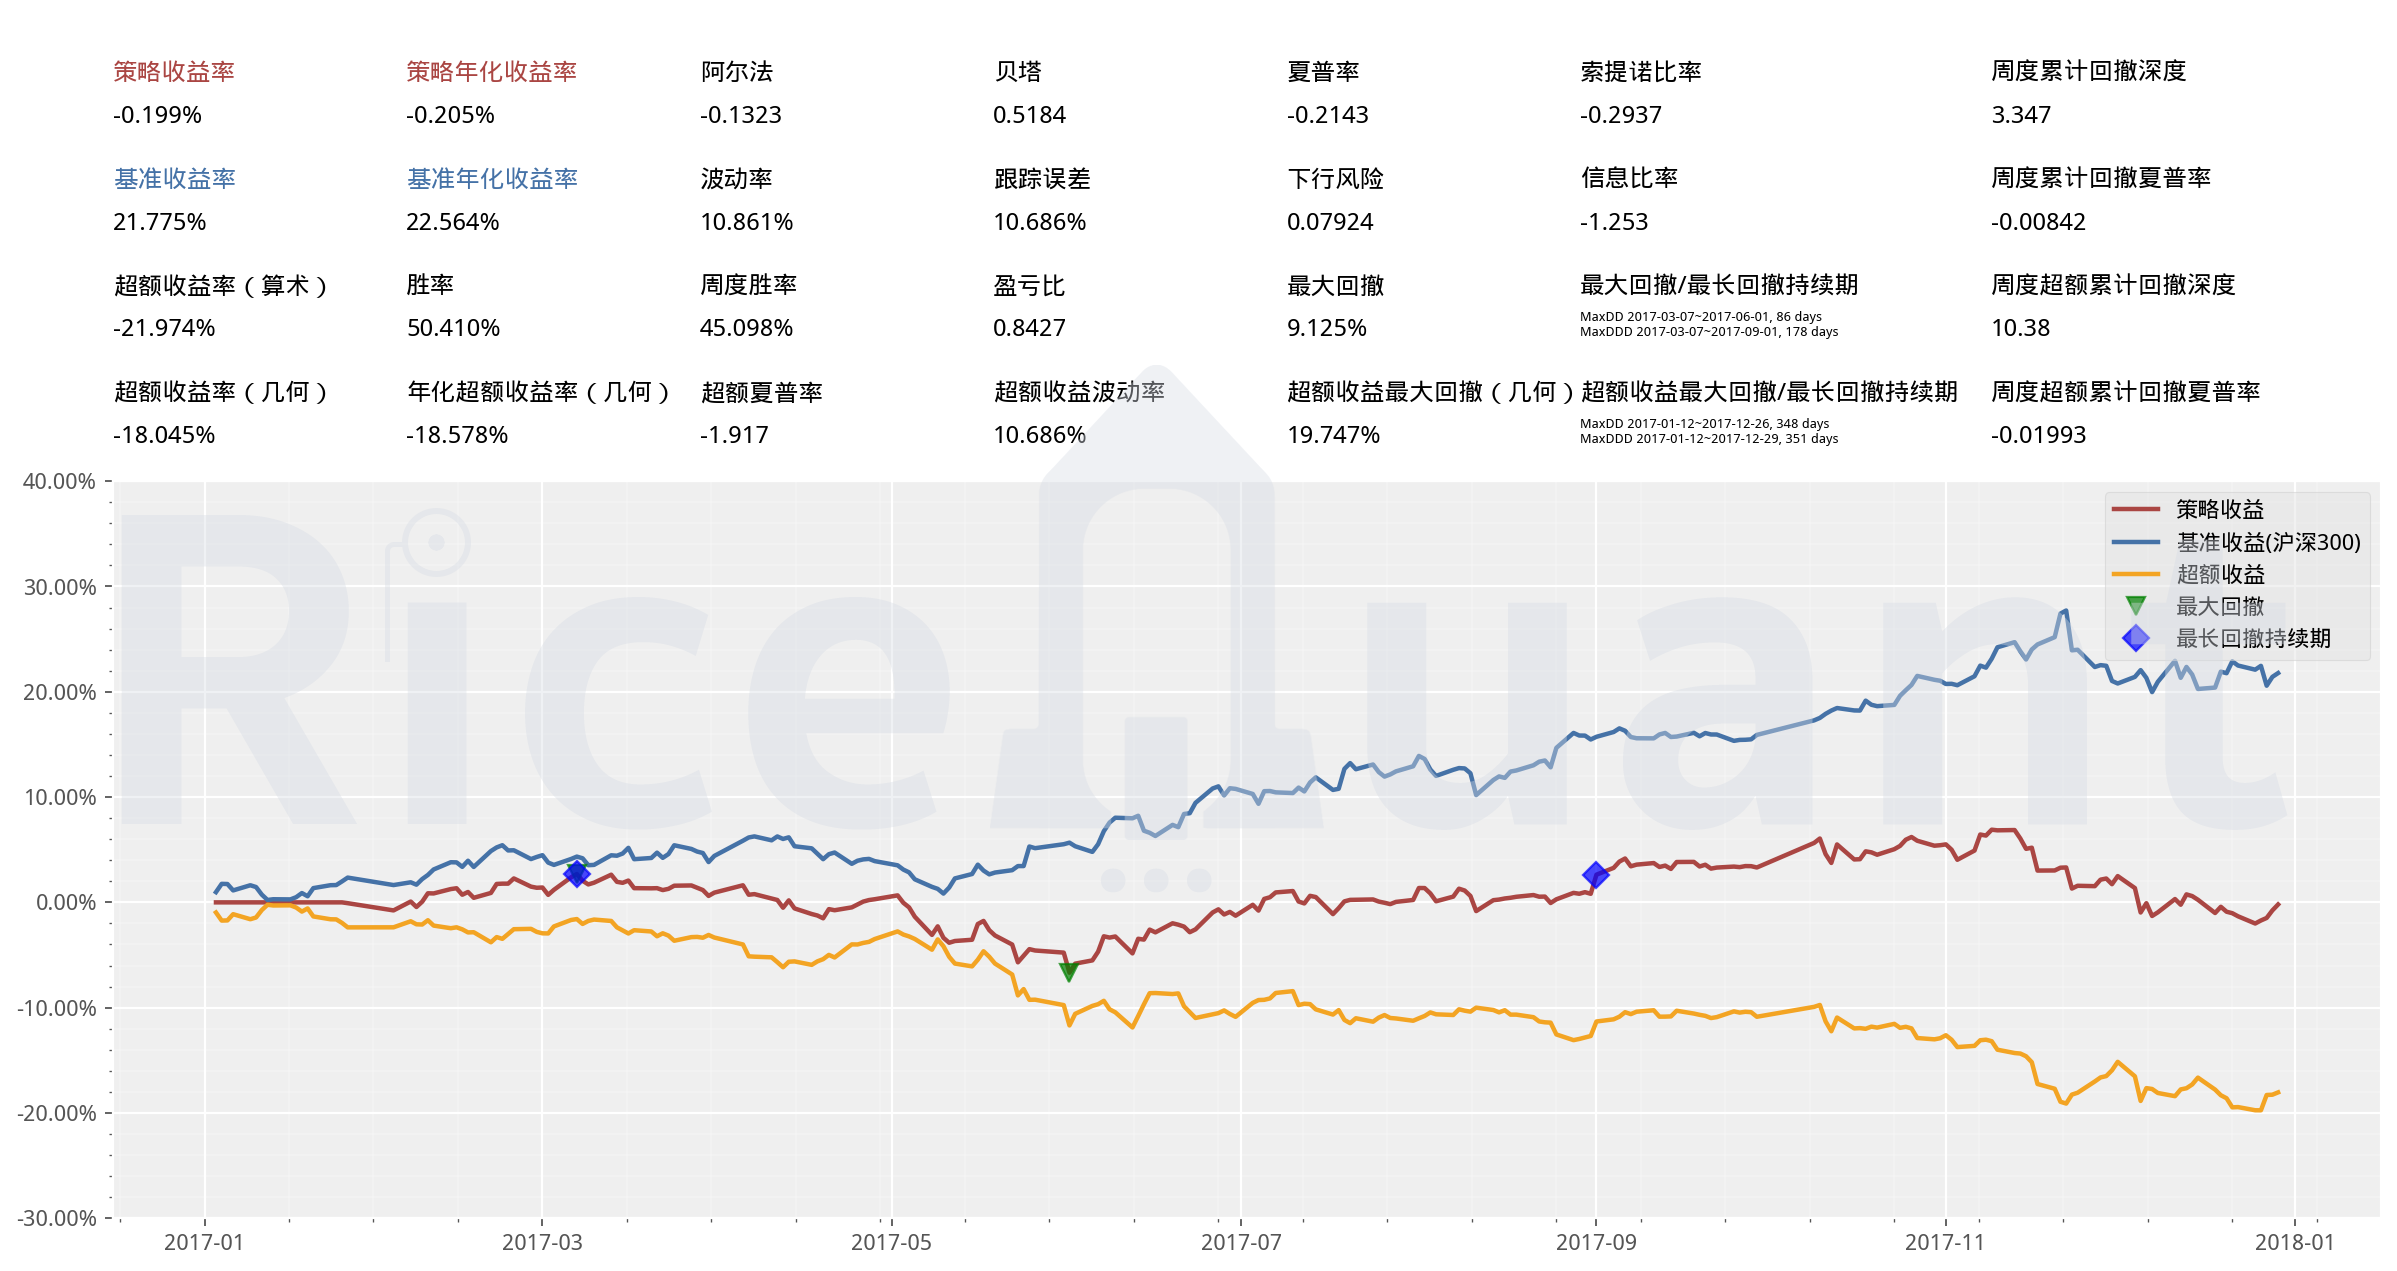

MultiOLS_XGBoost在2017


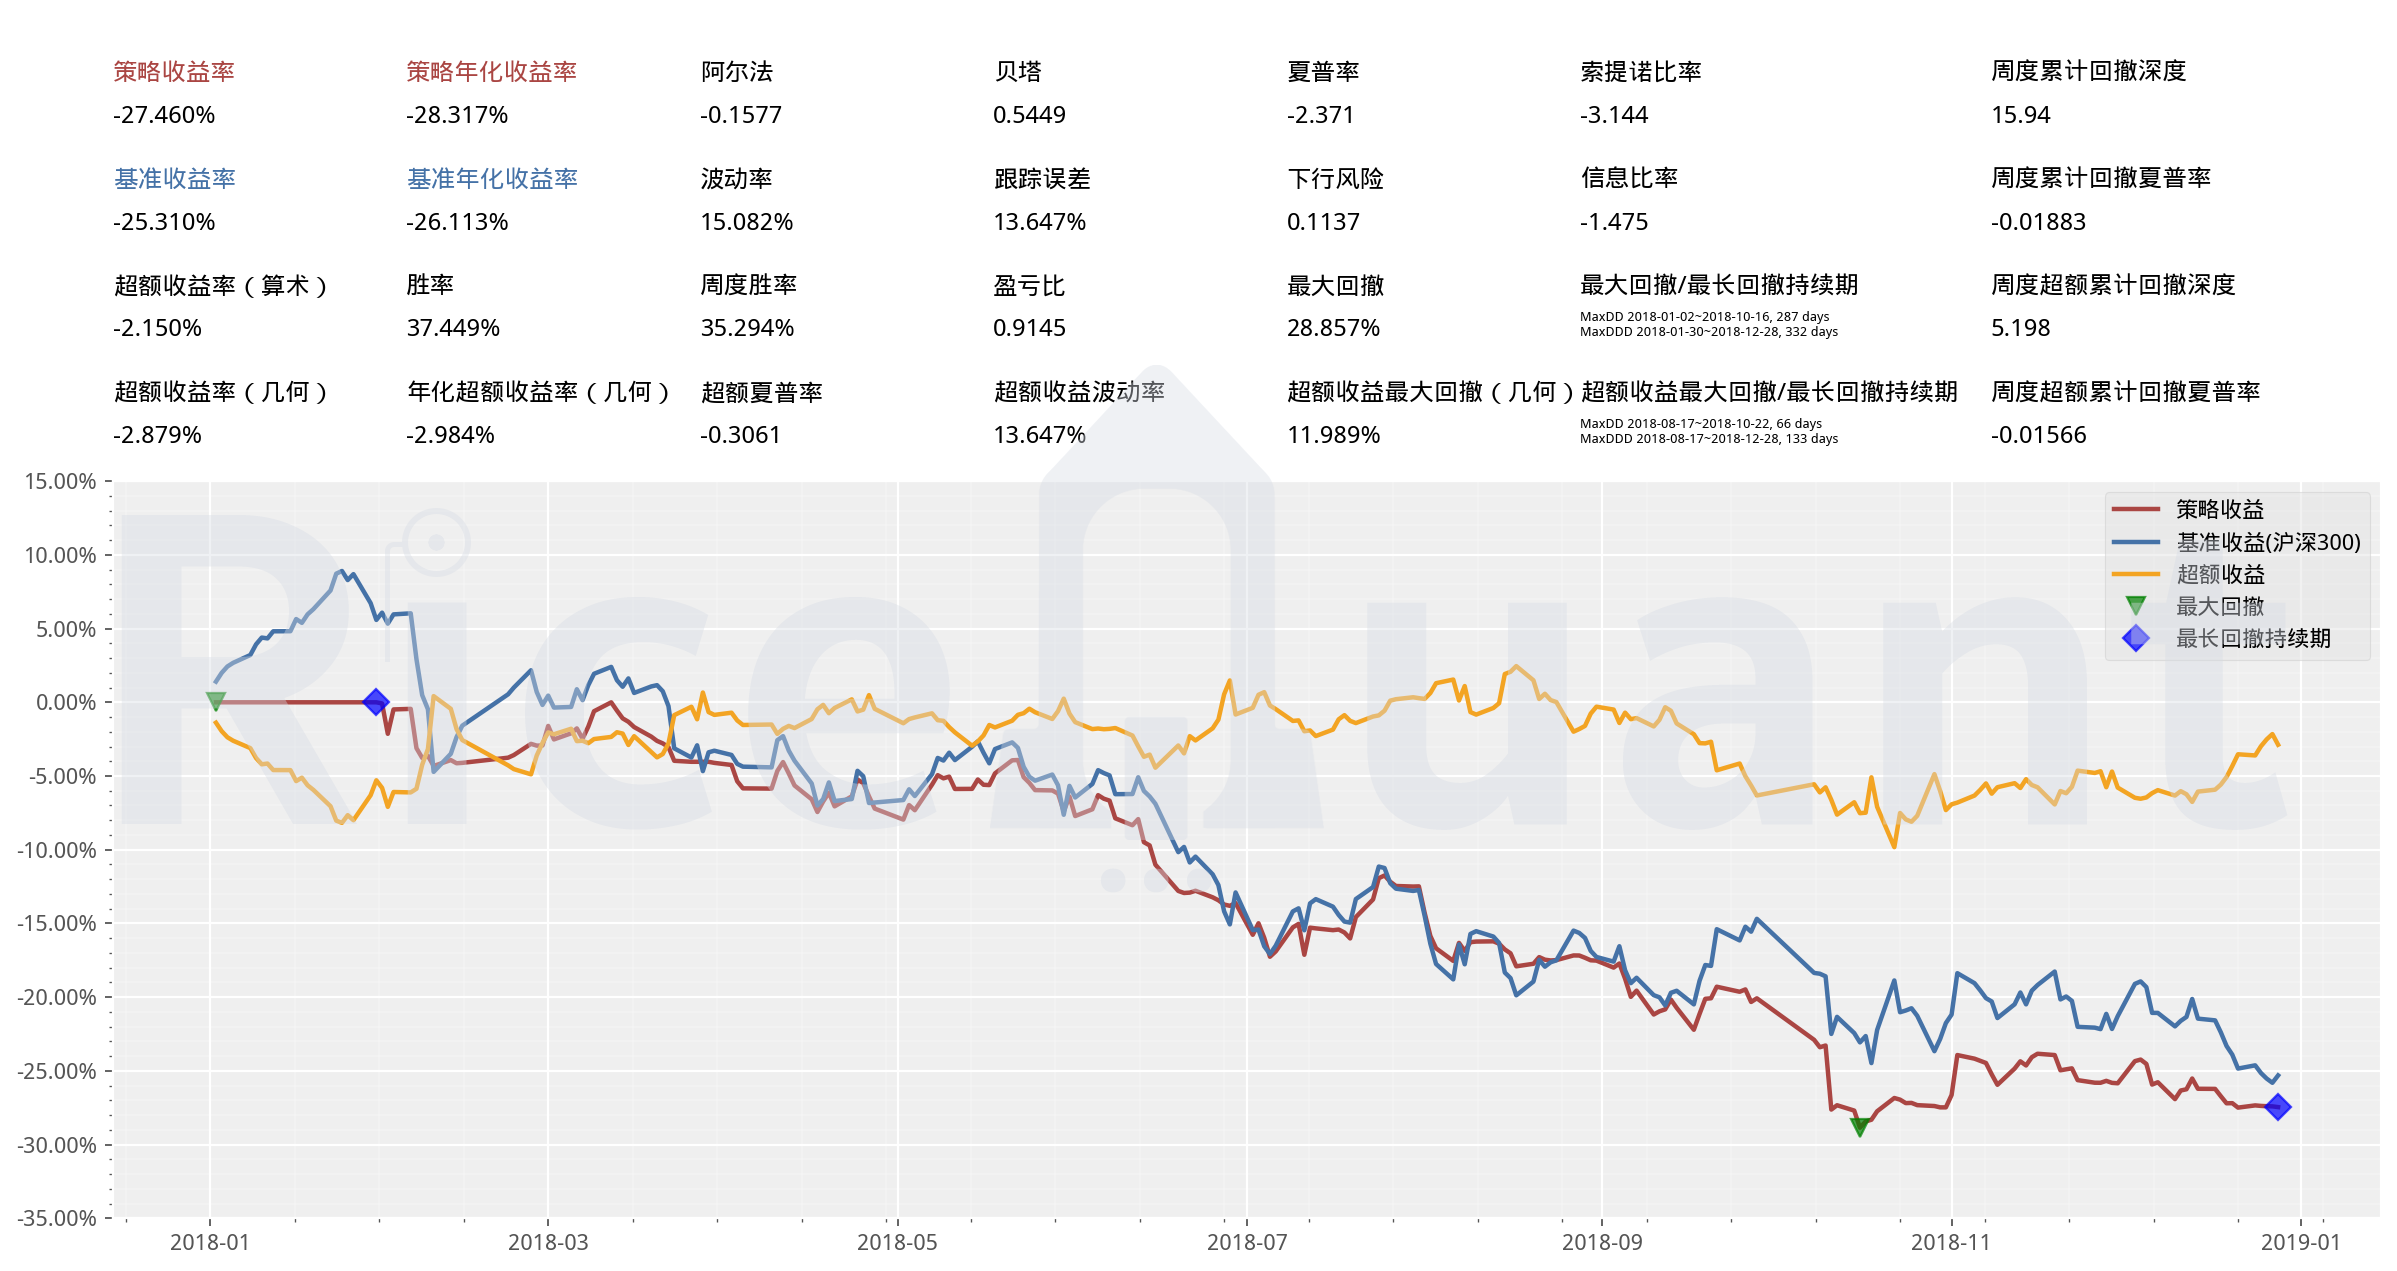

MultiOLS_XGBoost在2018


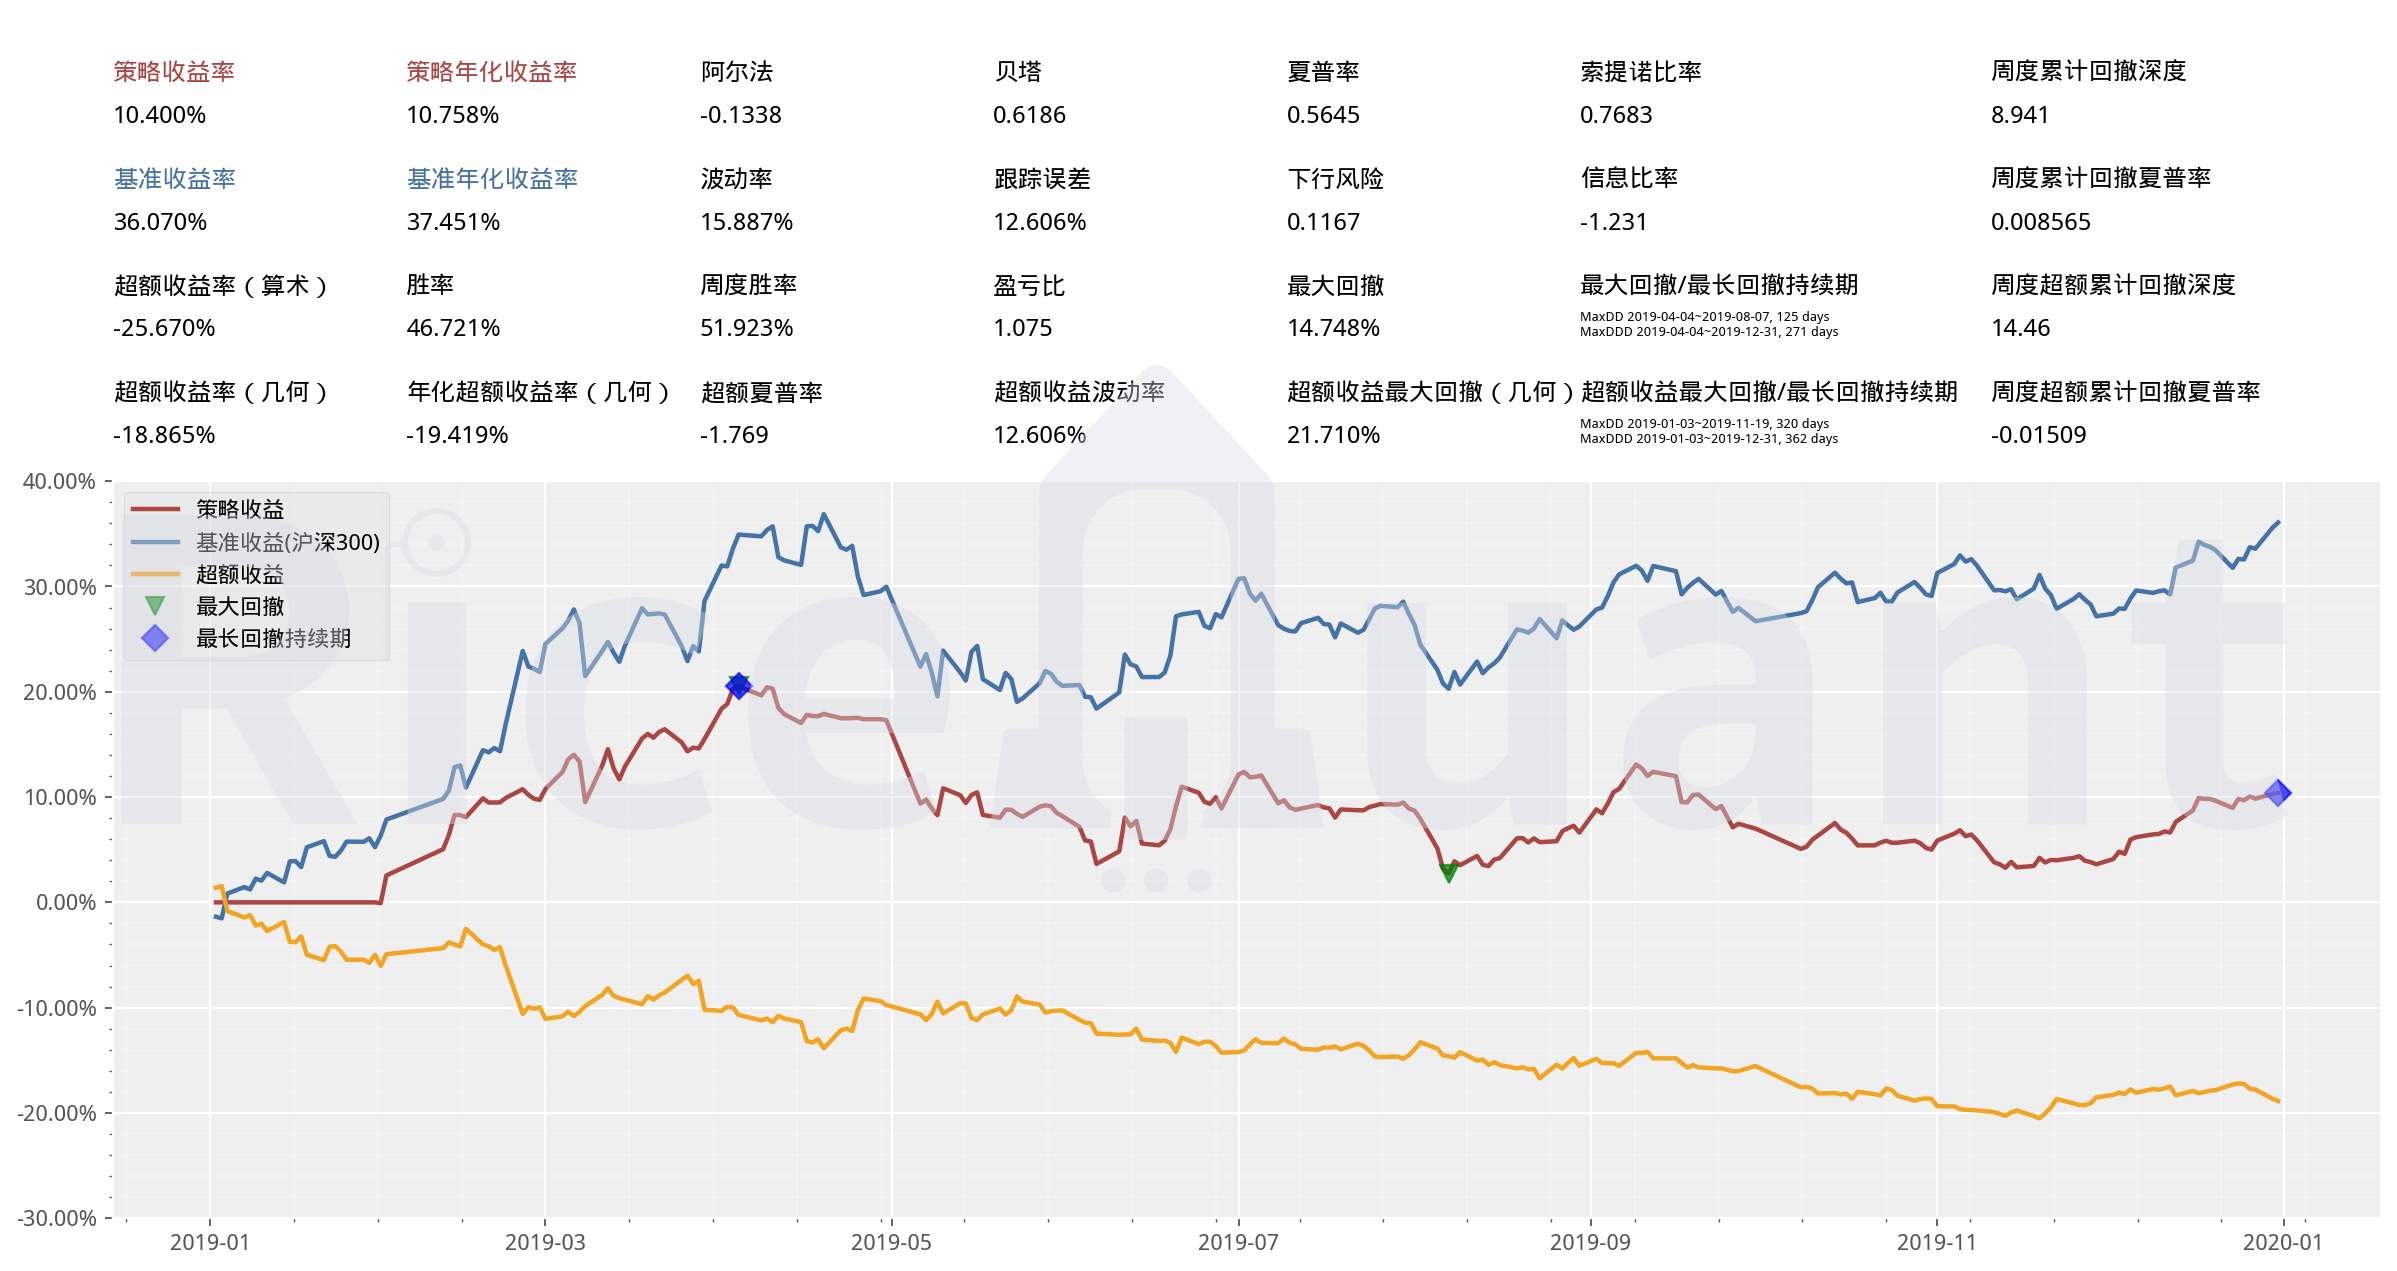

MultiOLS_XGBoost在2019


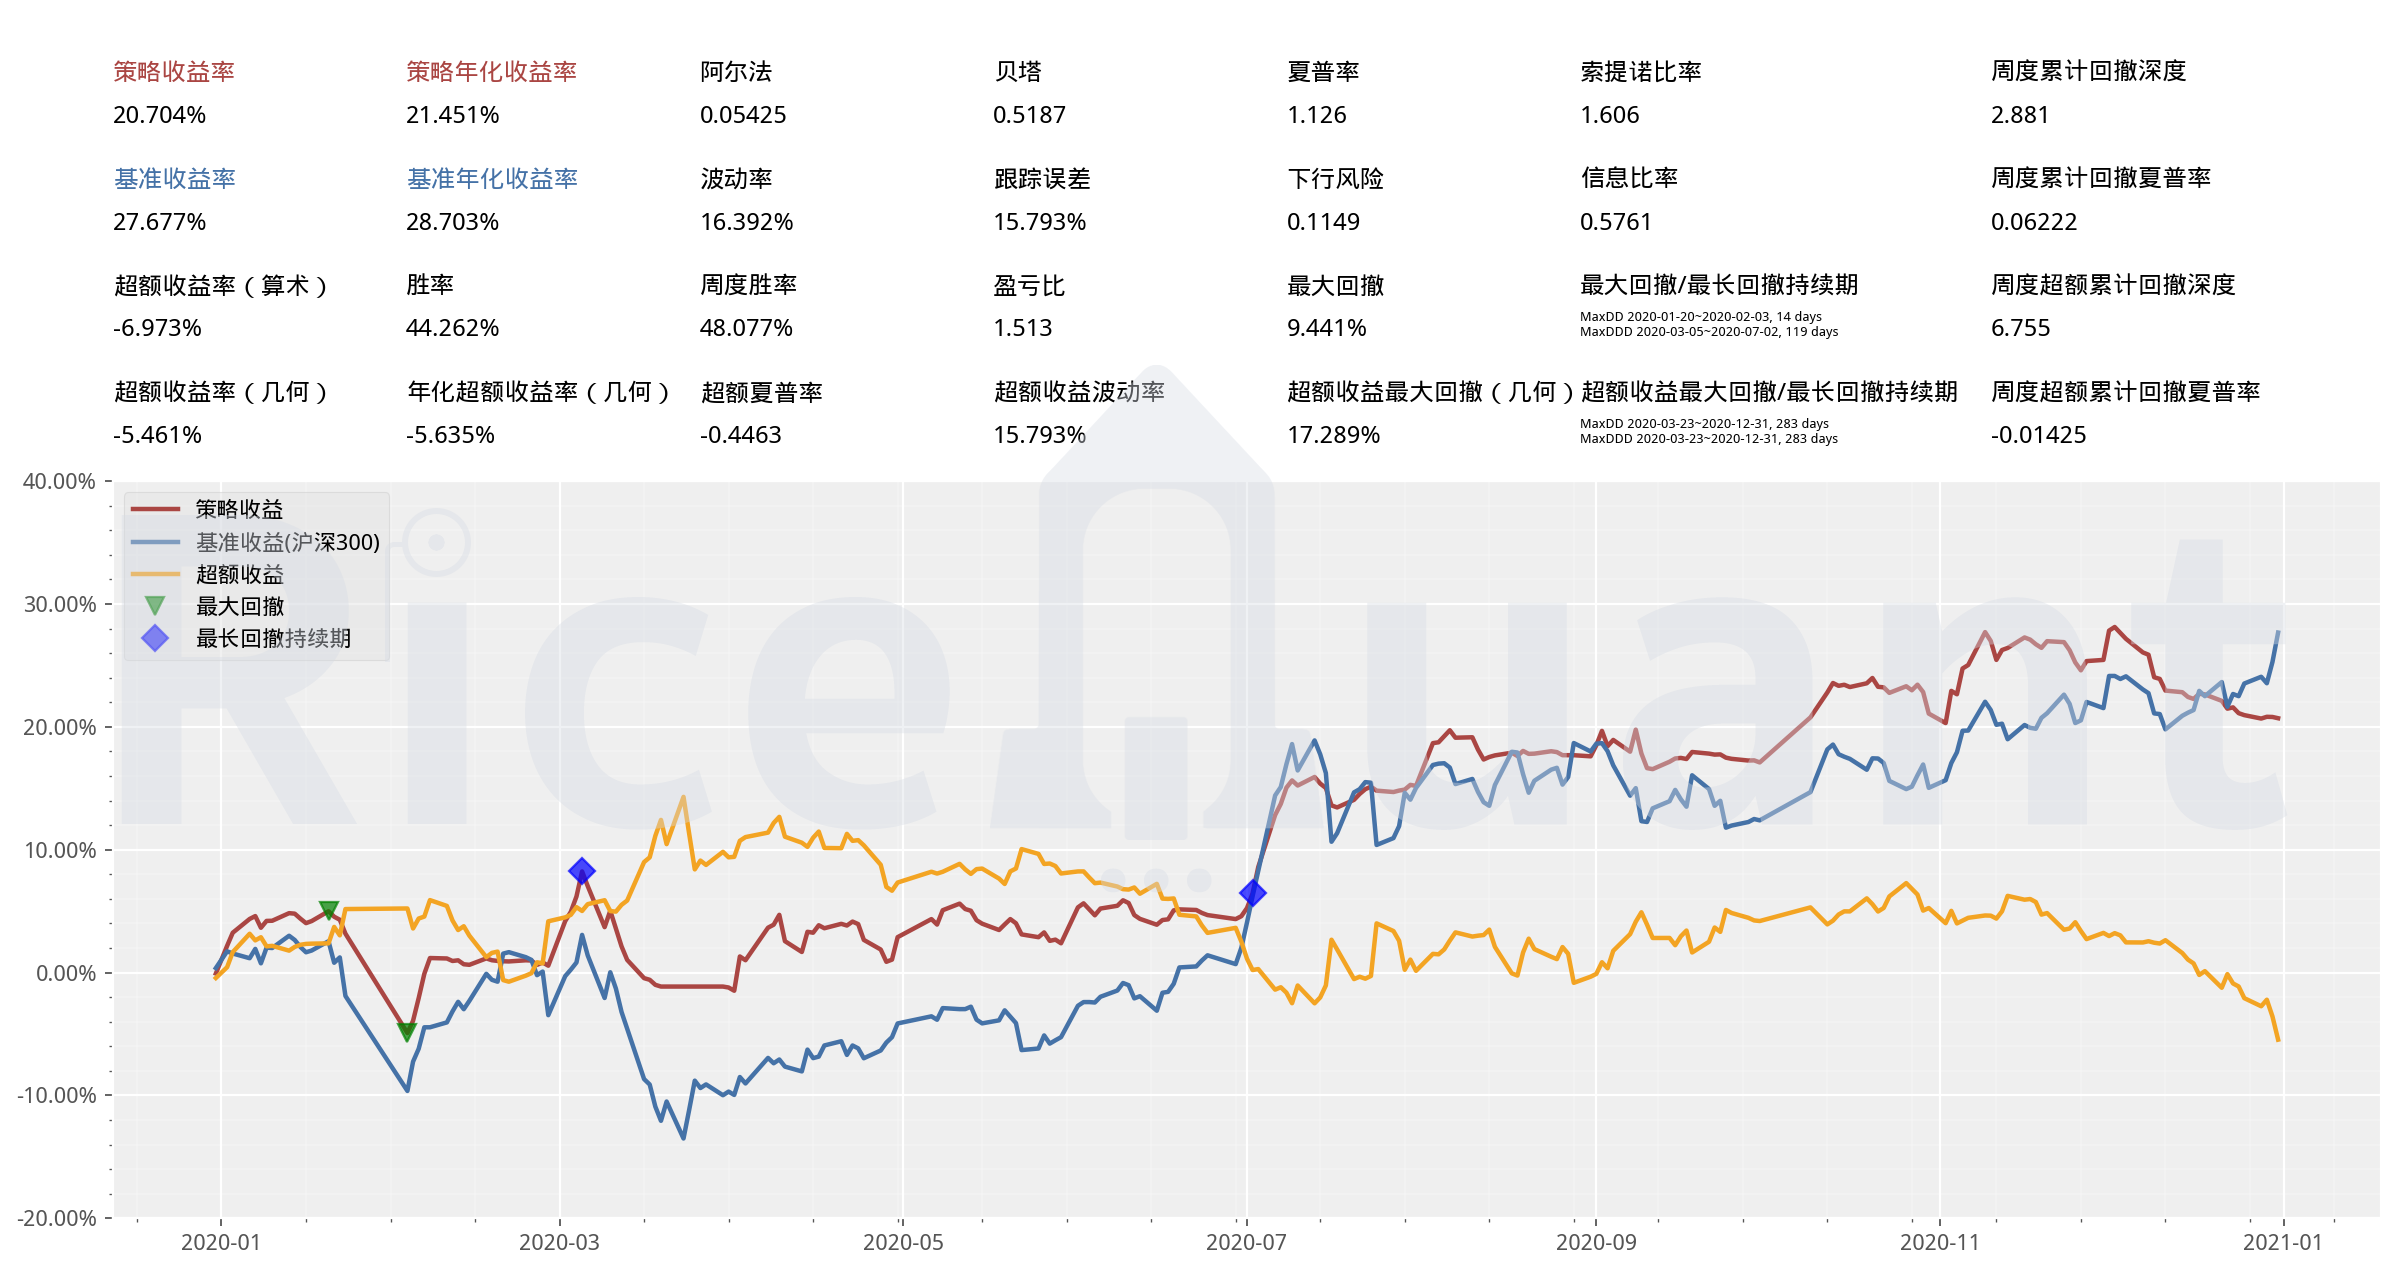

MultiOLS_XGBoost在2020


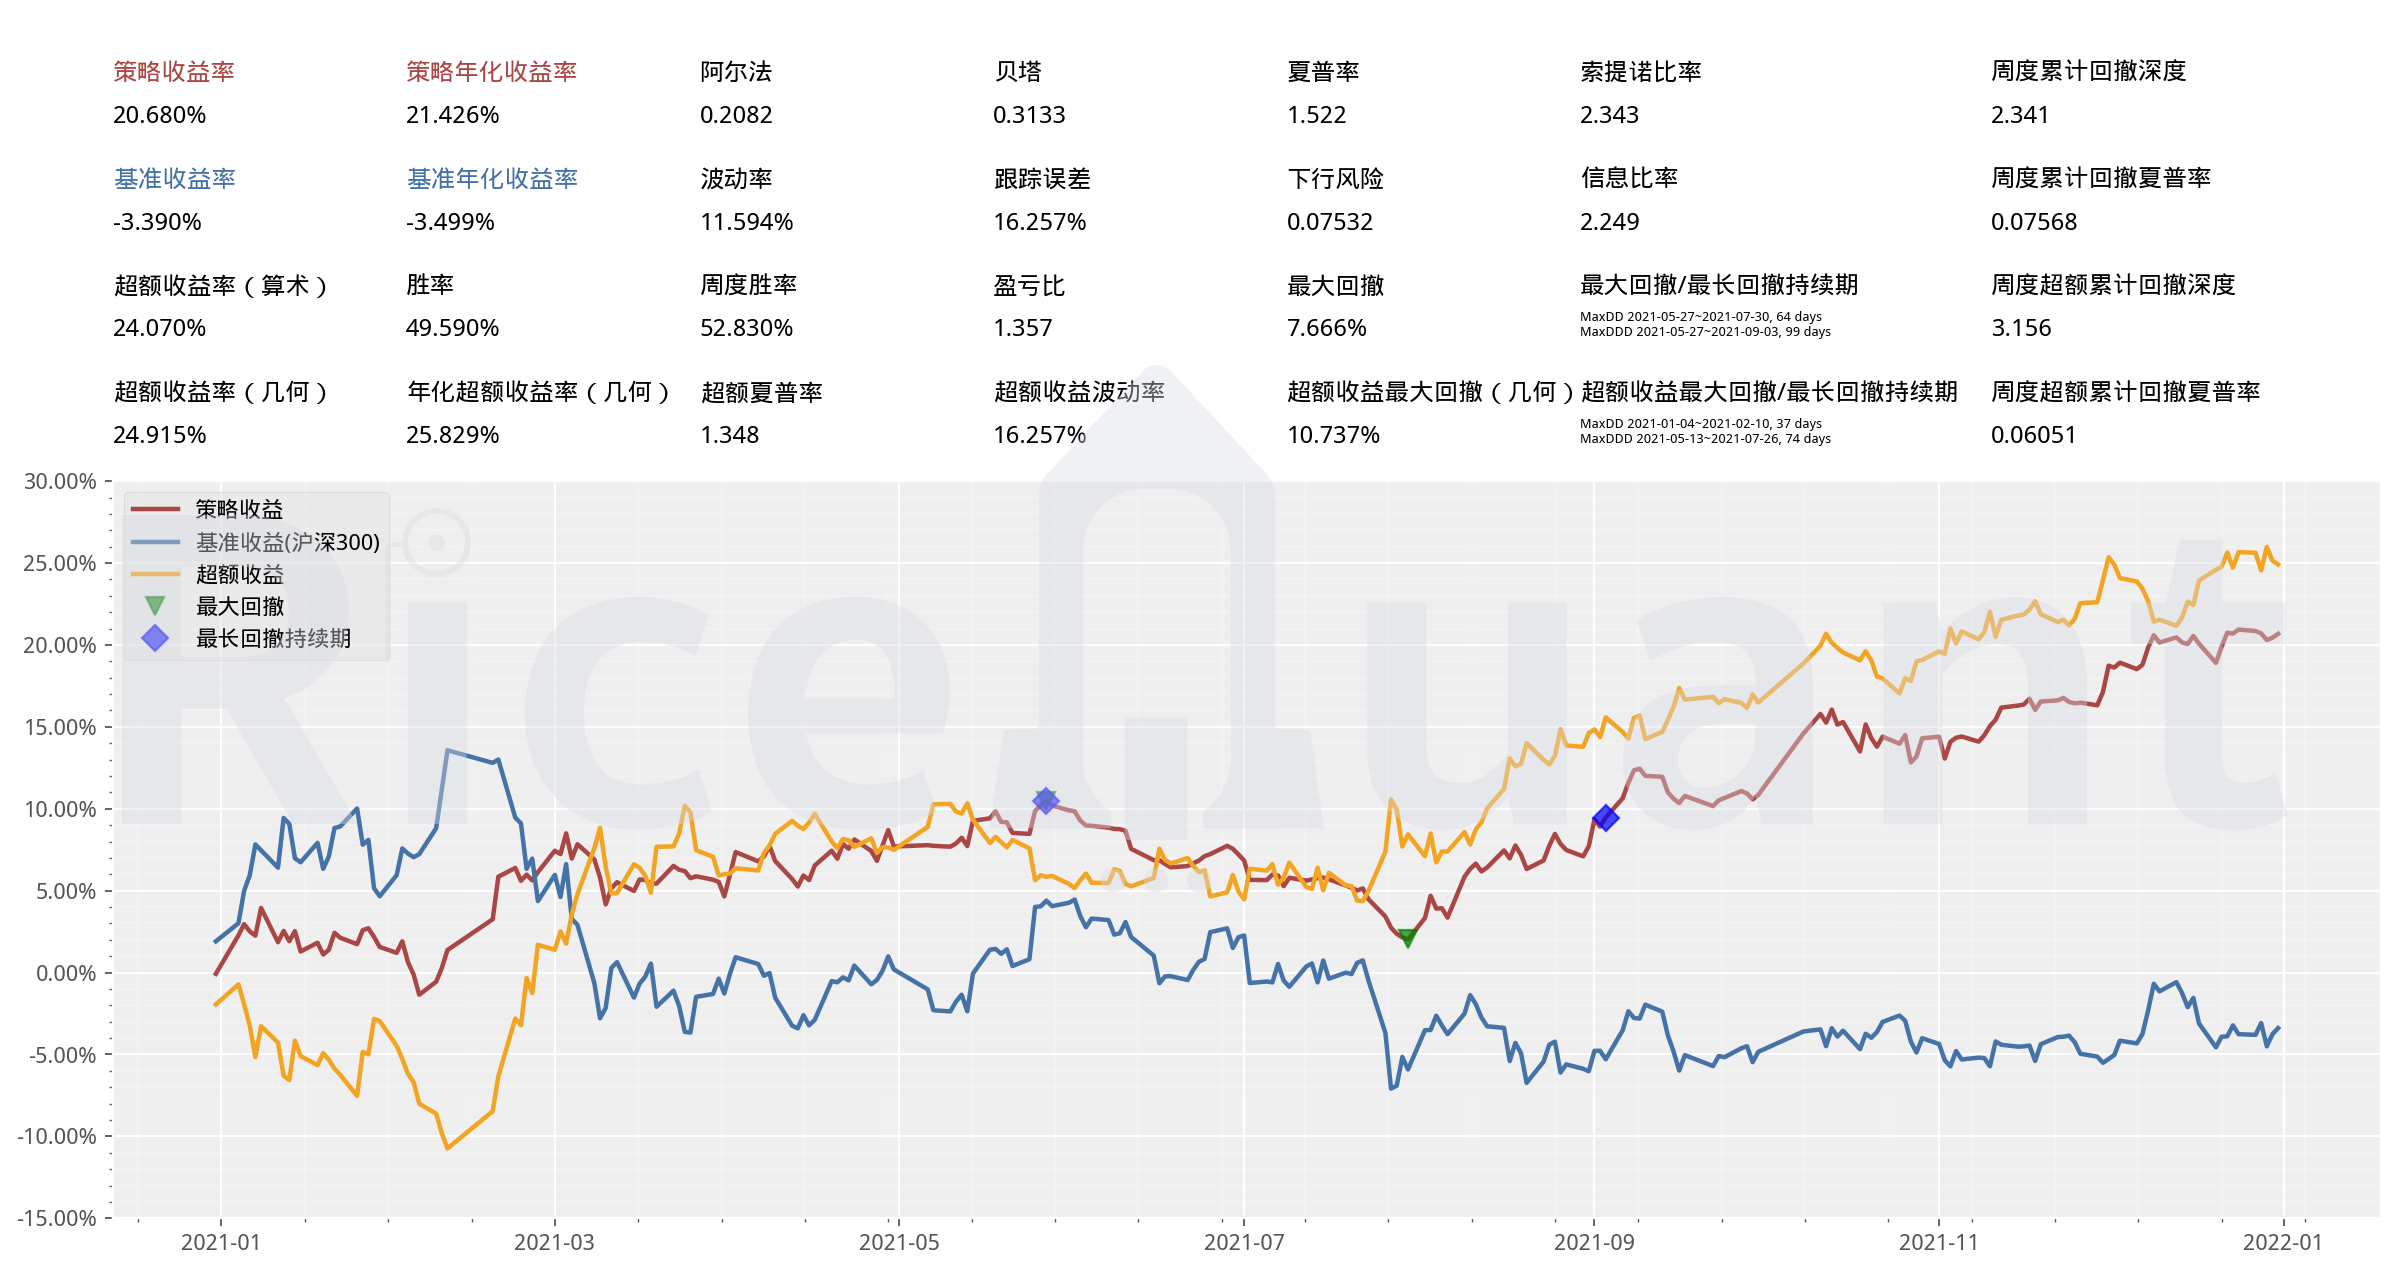

MultiOLS_XGBoost在2021


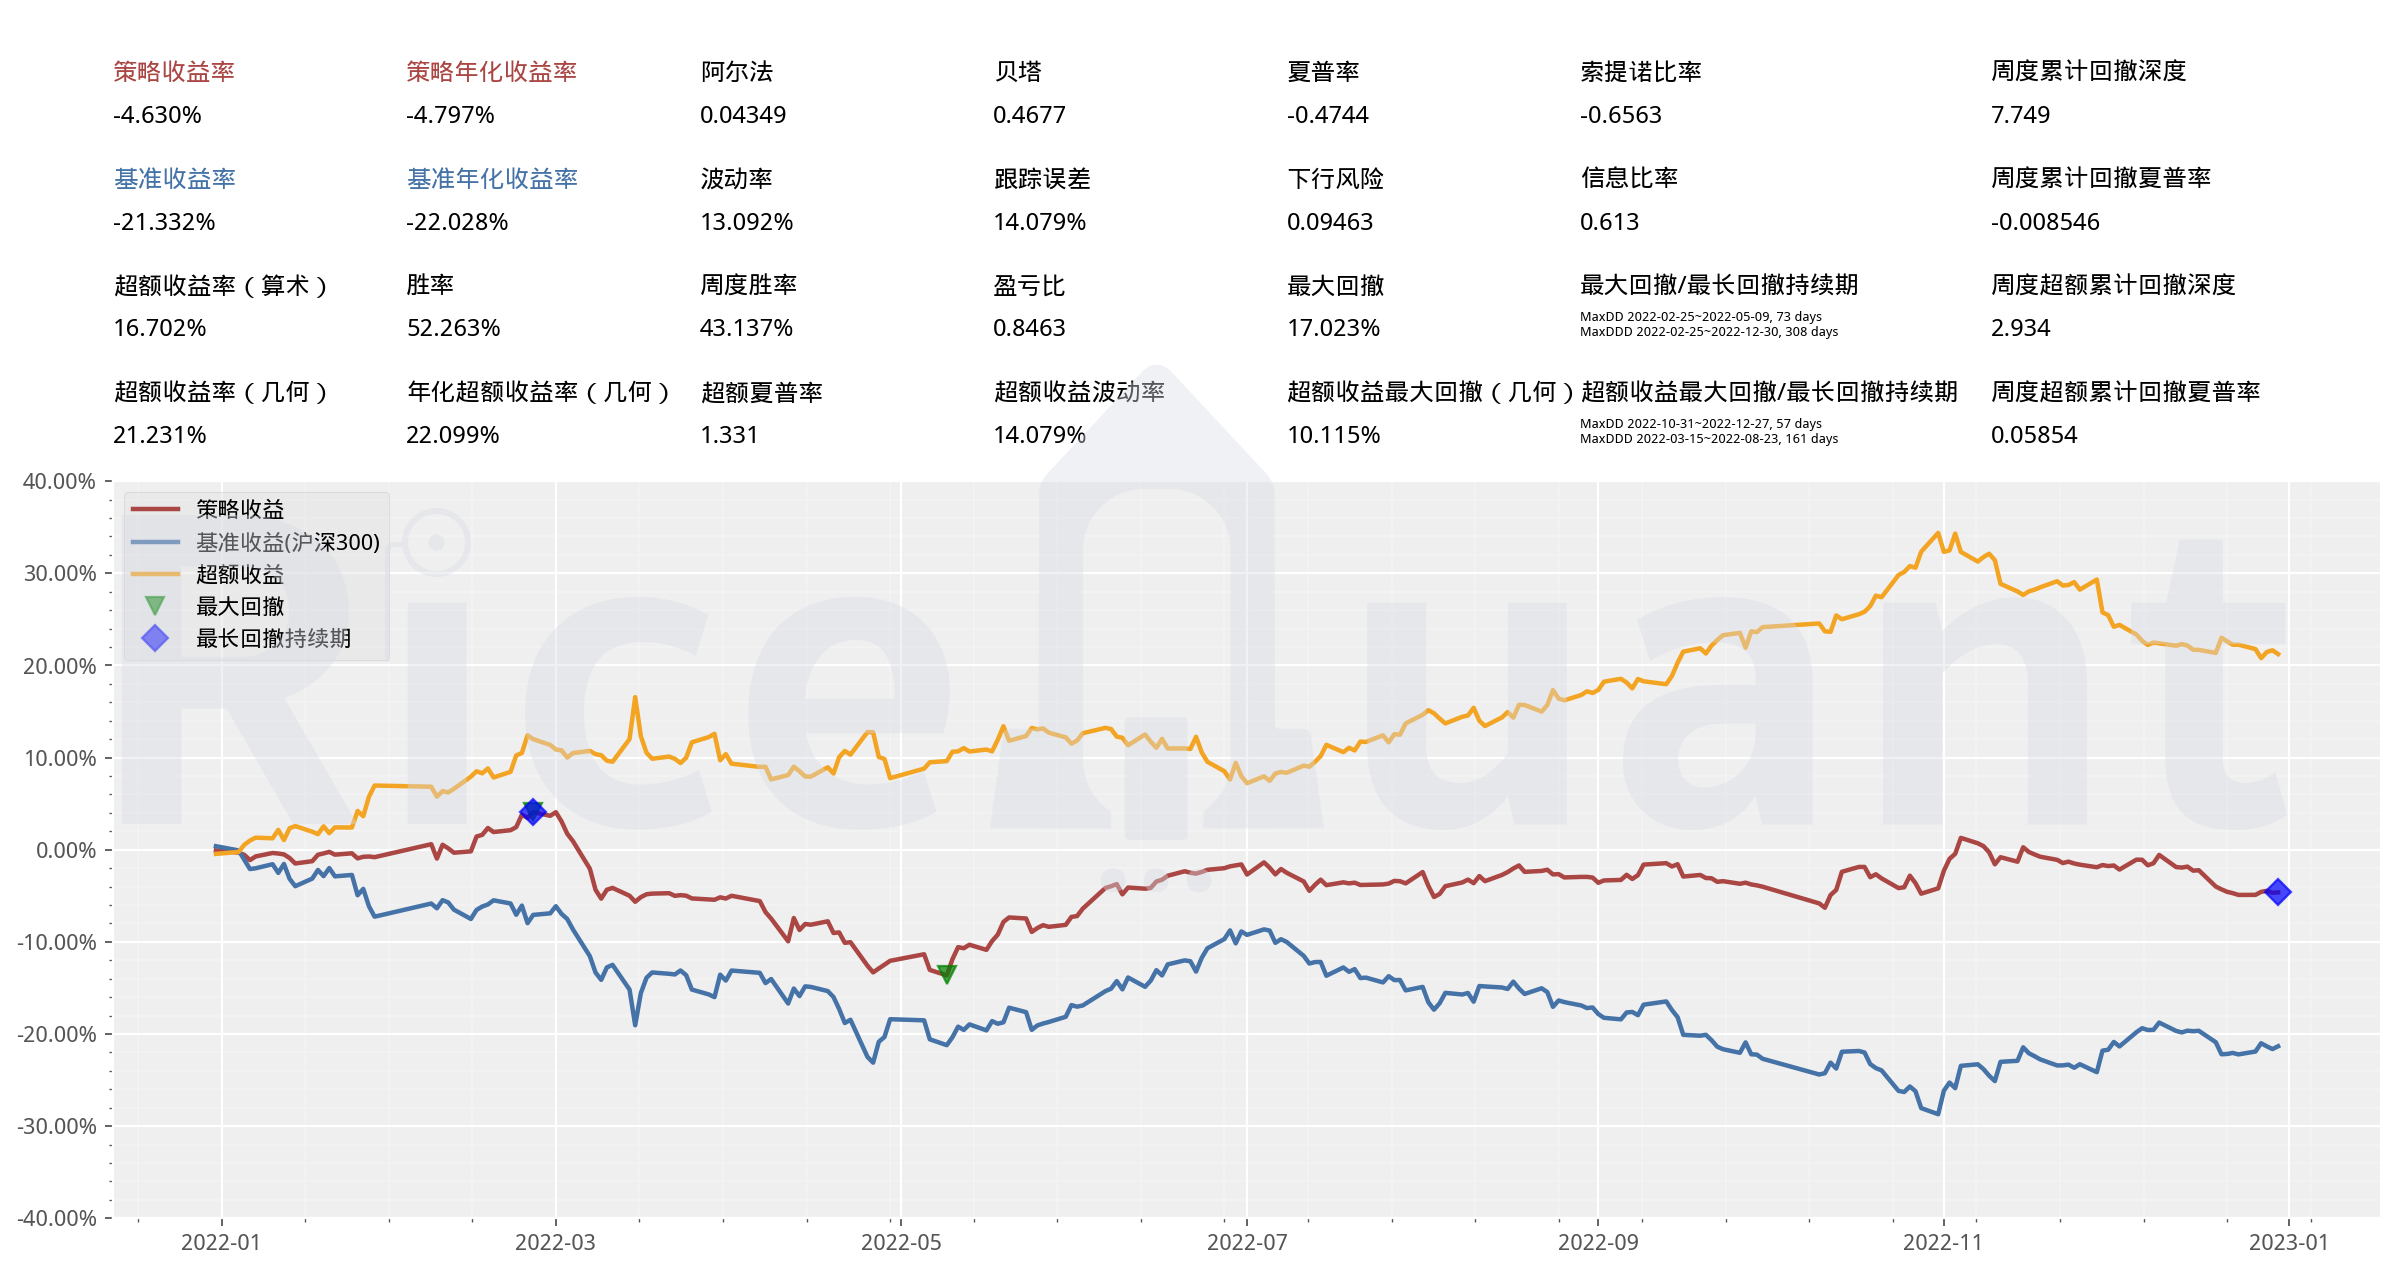

MultiOLS_XGBoost在2022


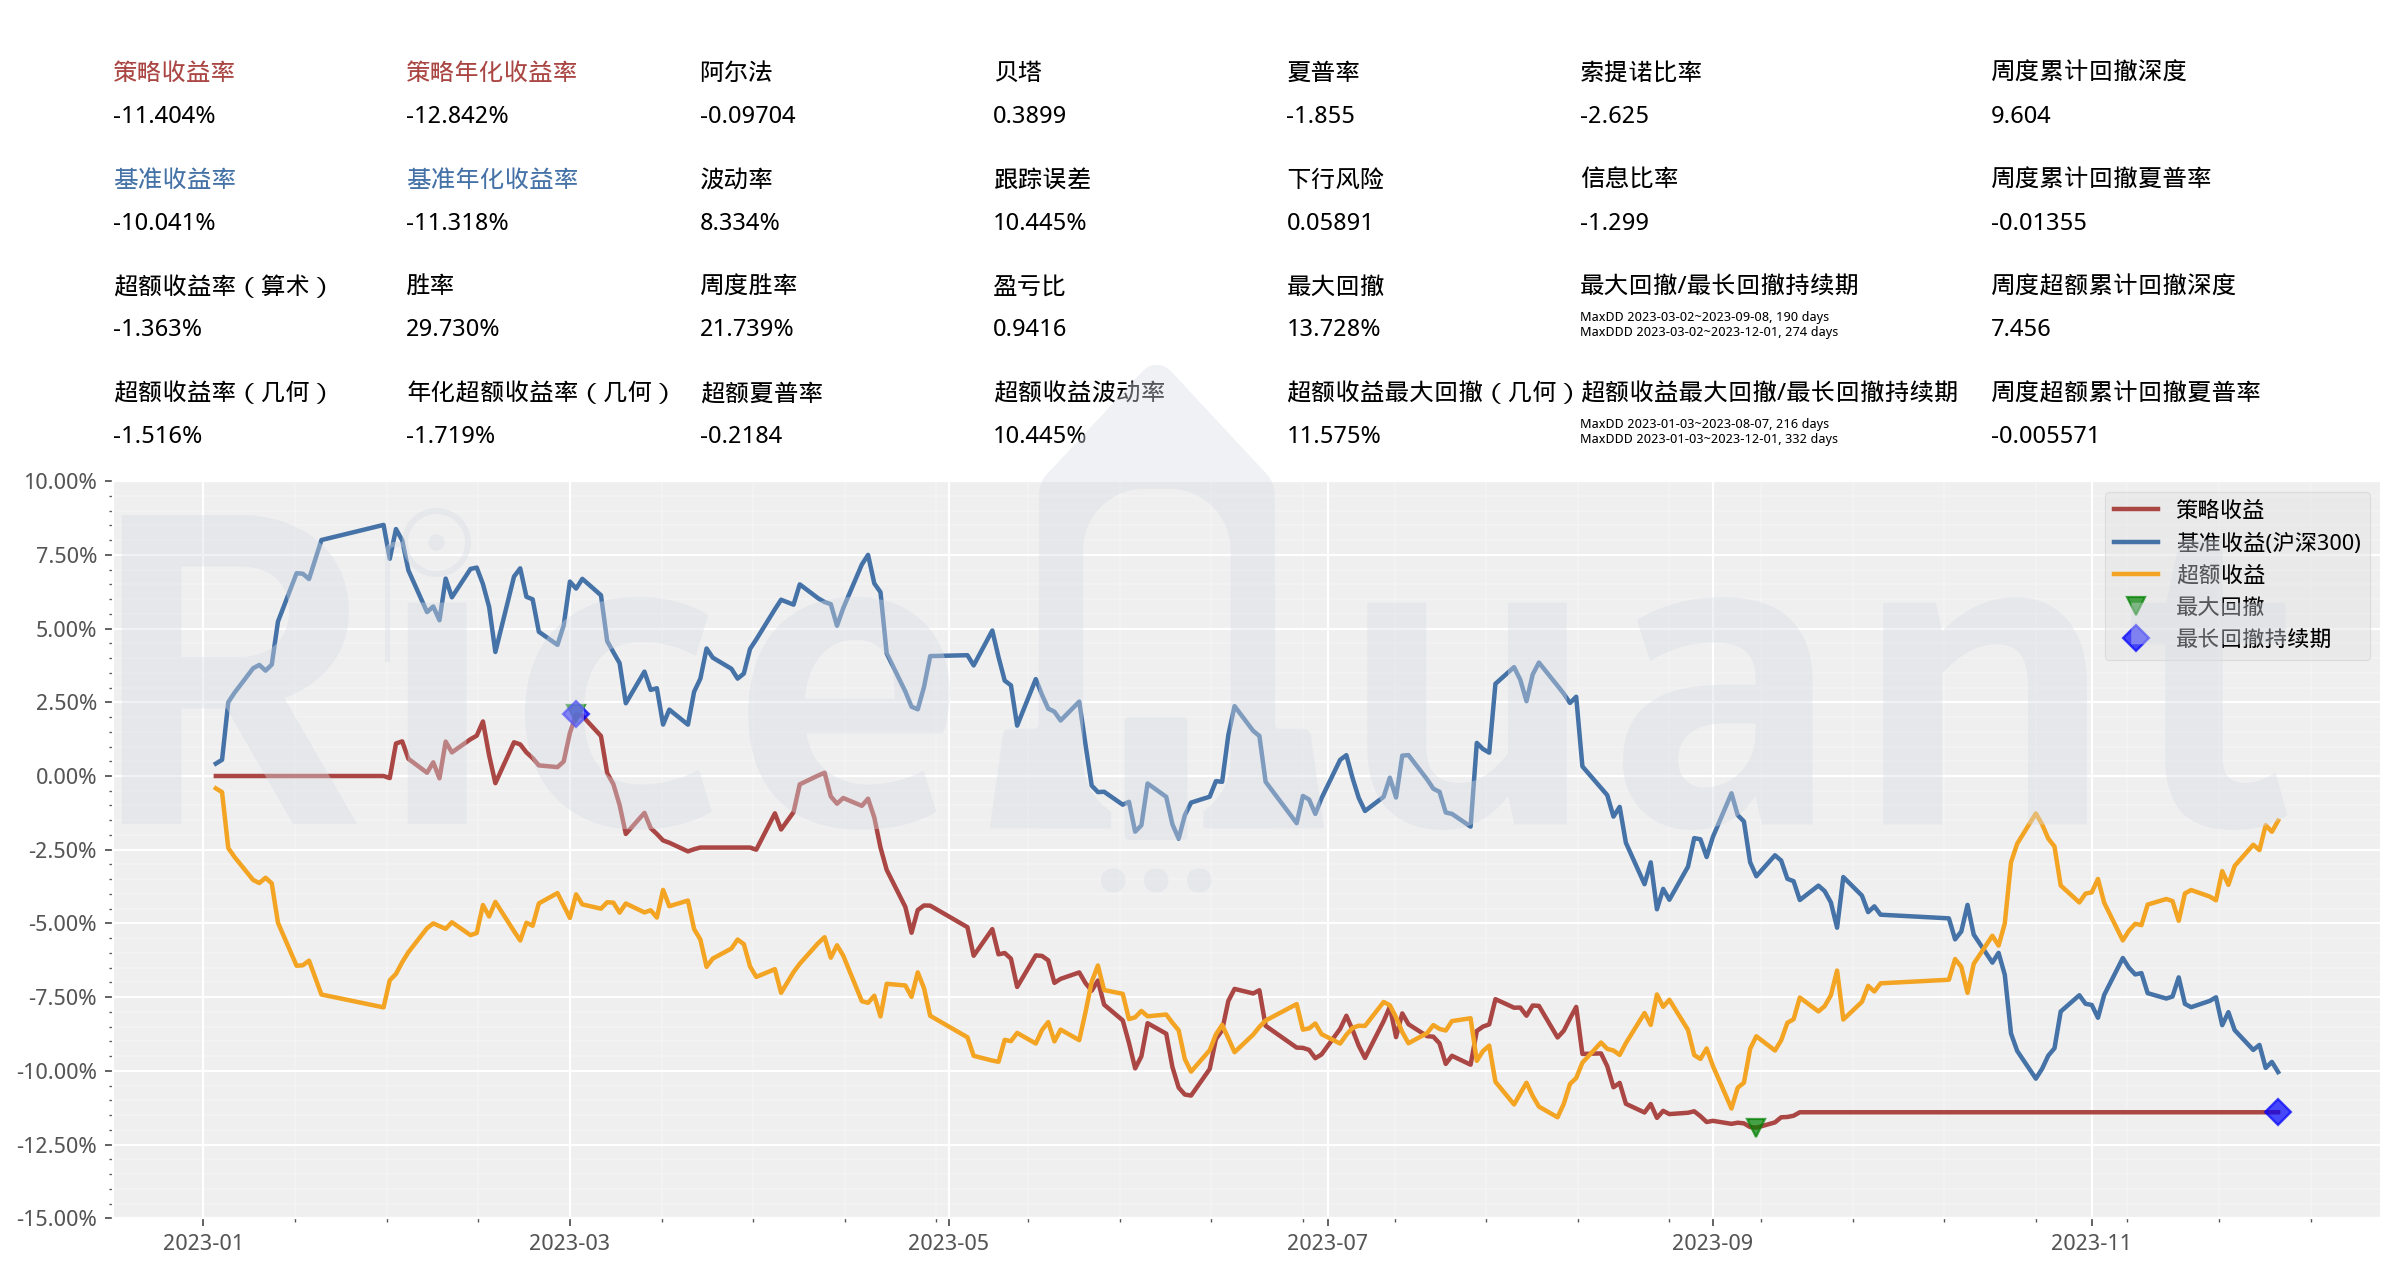

MultiOLS_rf在2015


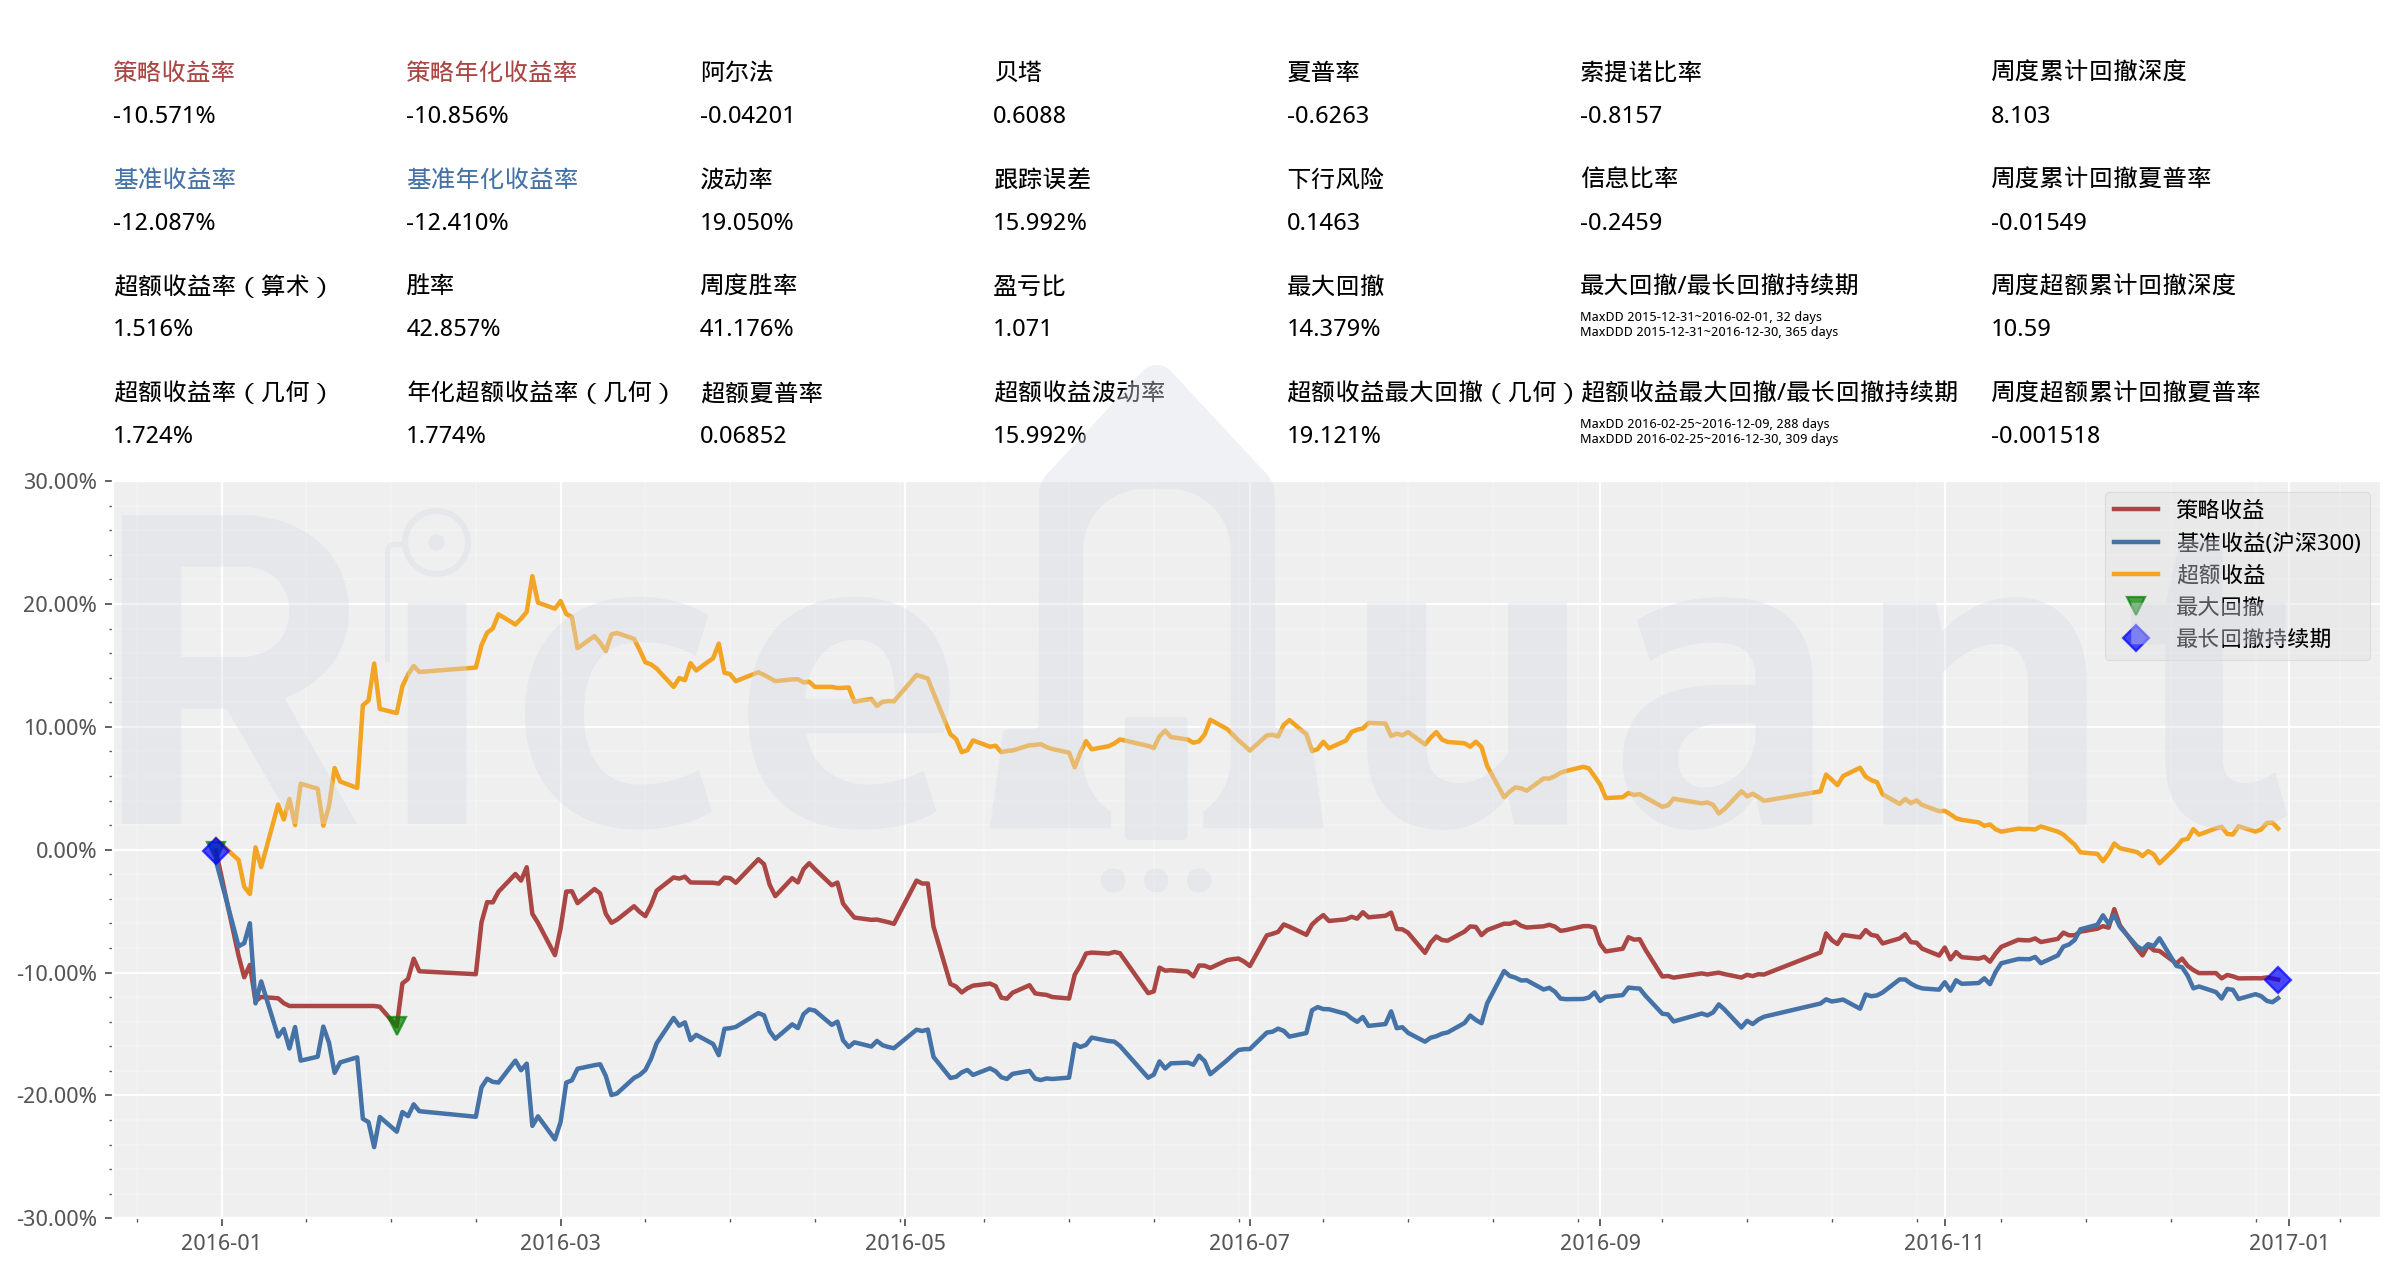

MultiOLS_rf在2016


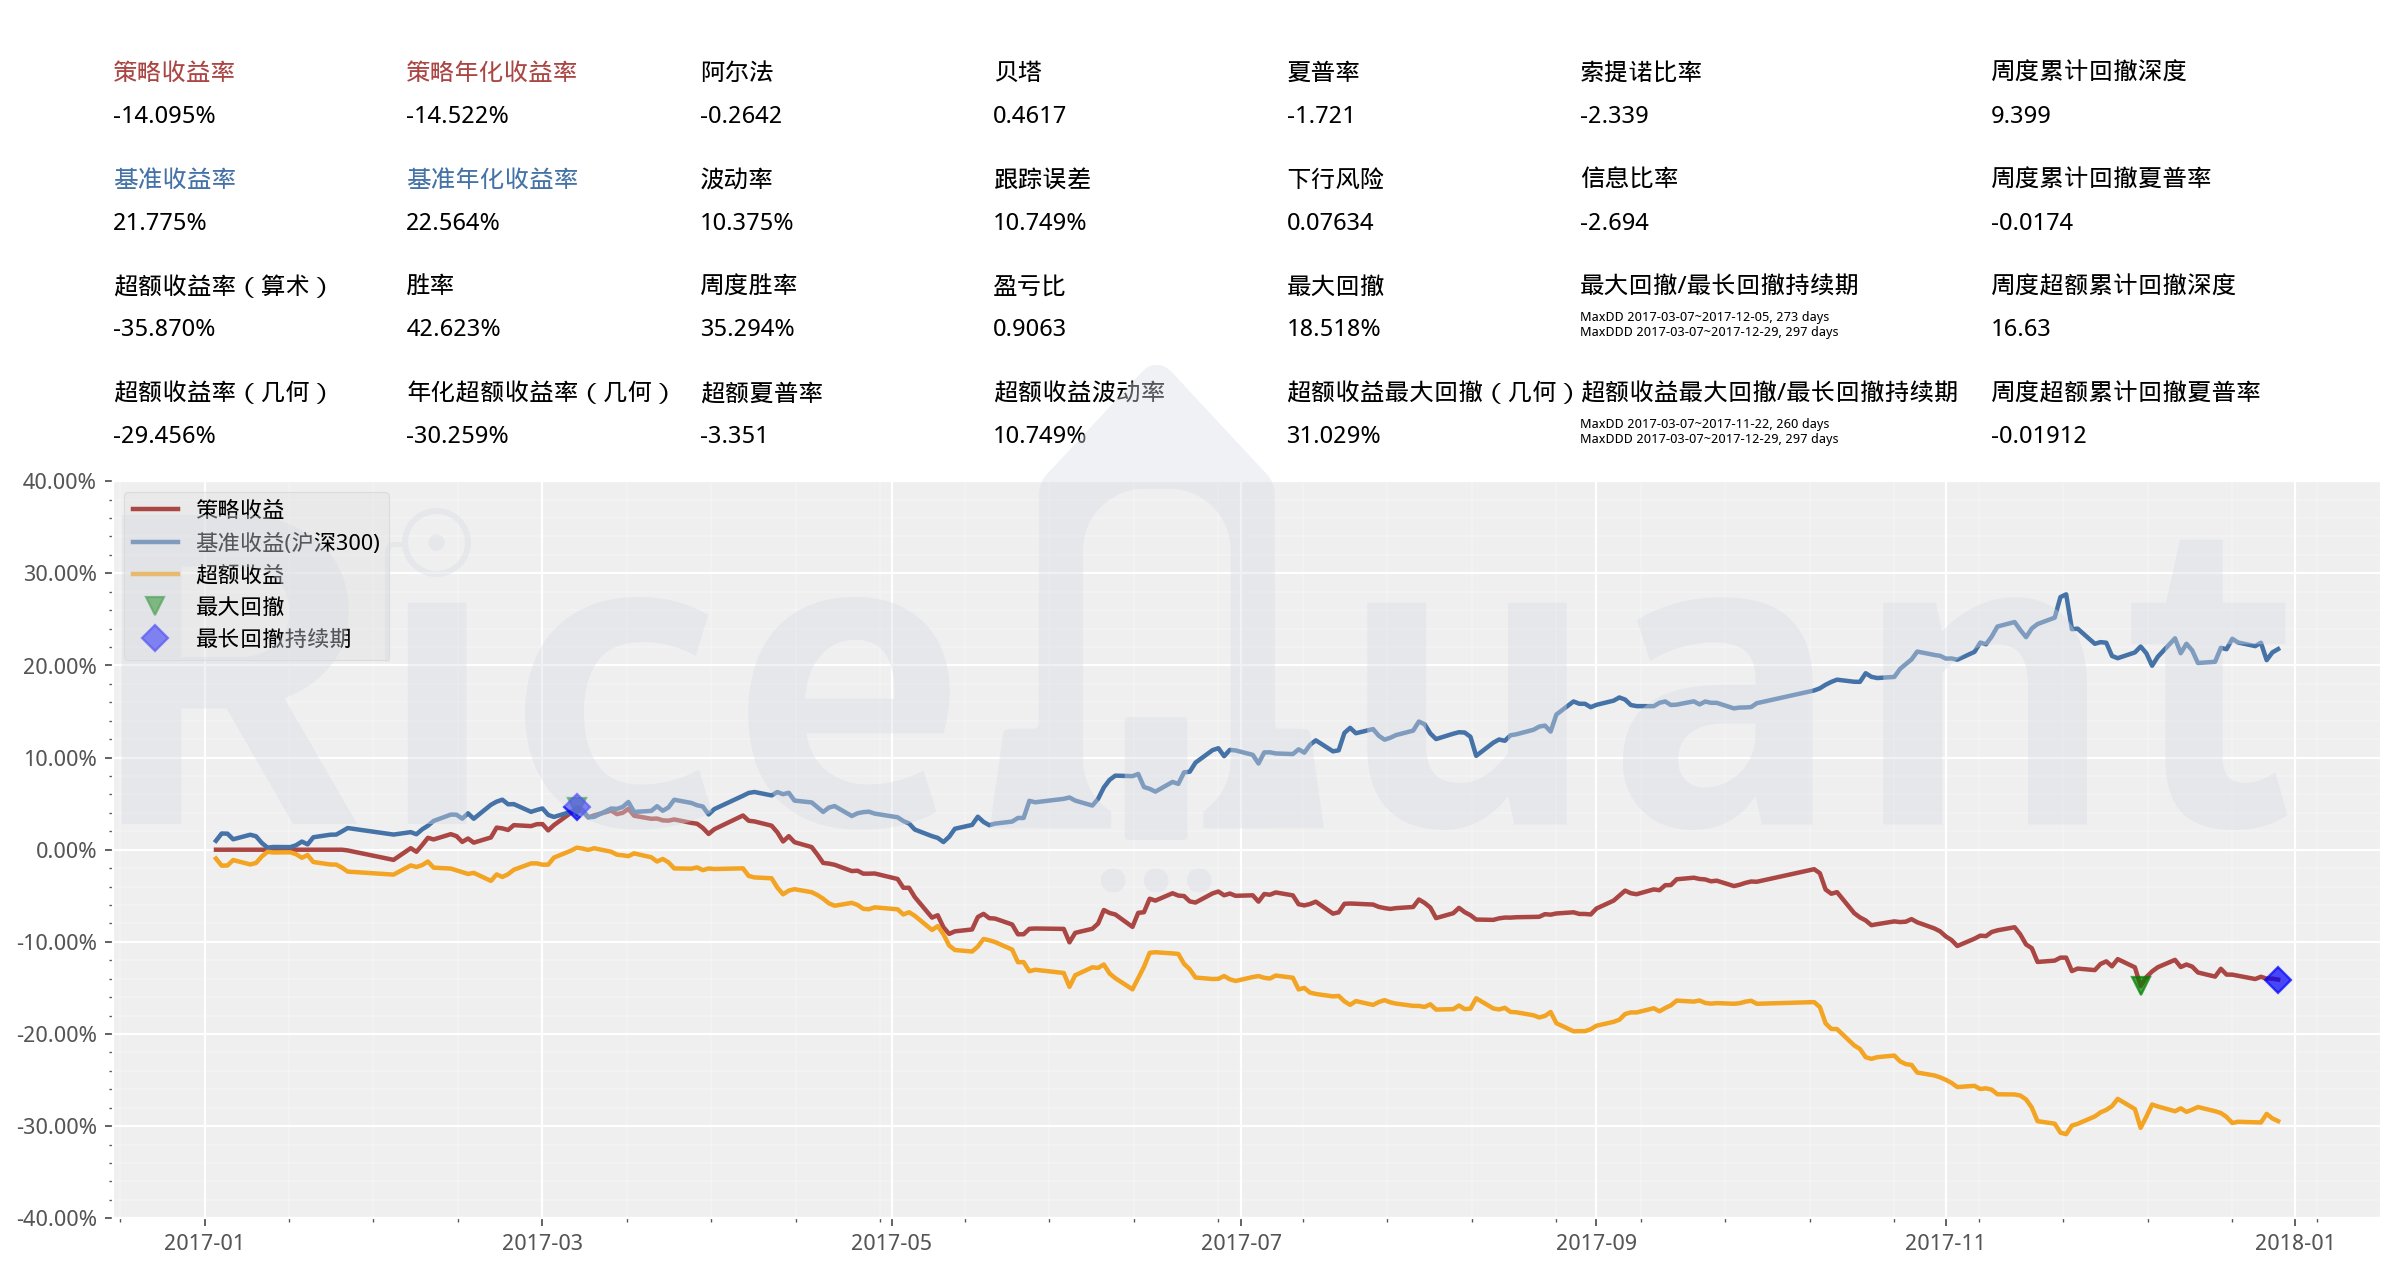

MultiOLS_rf在2017


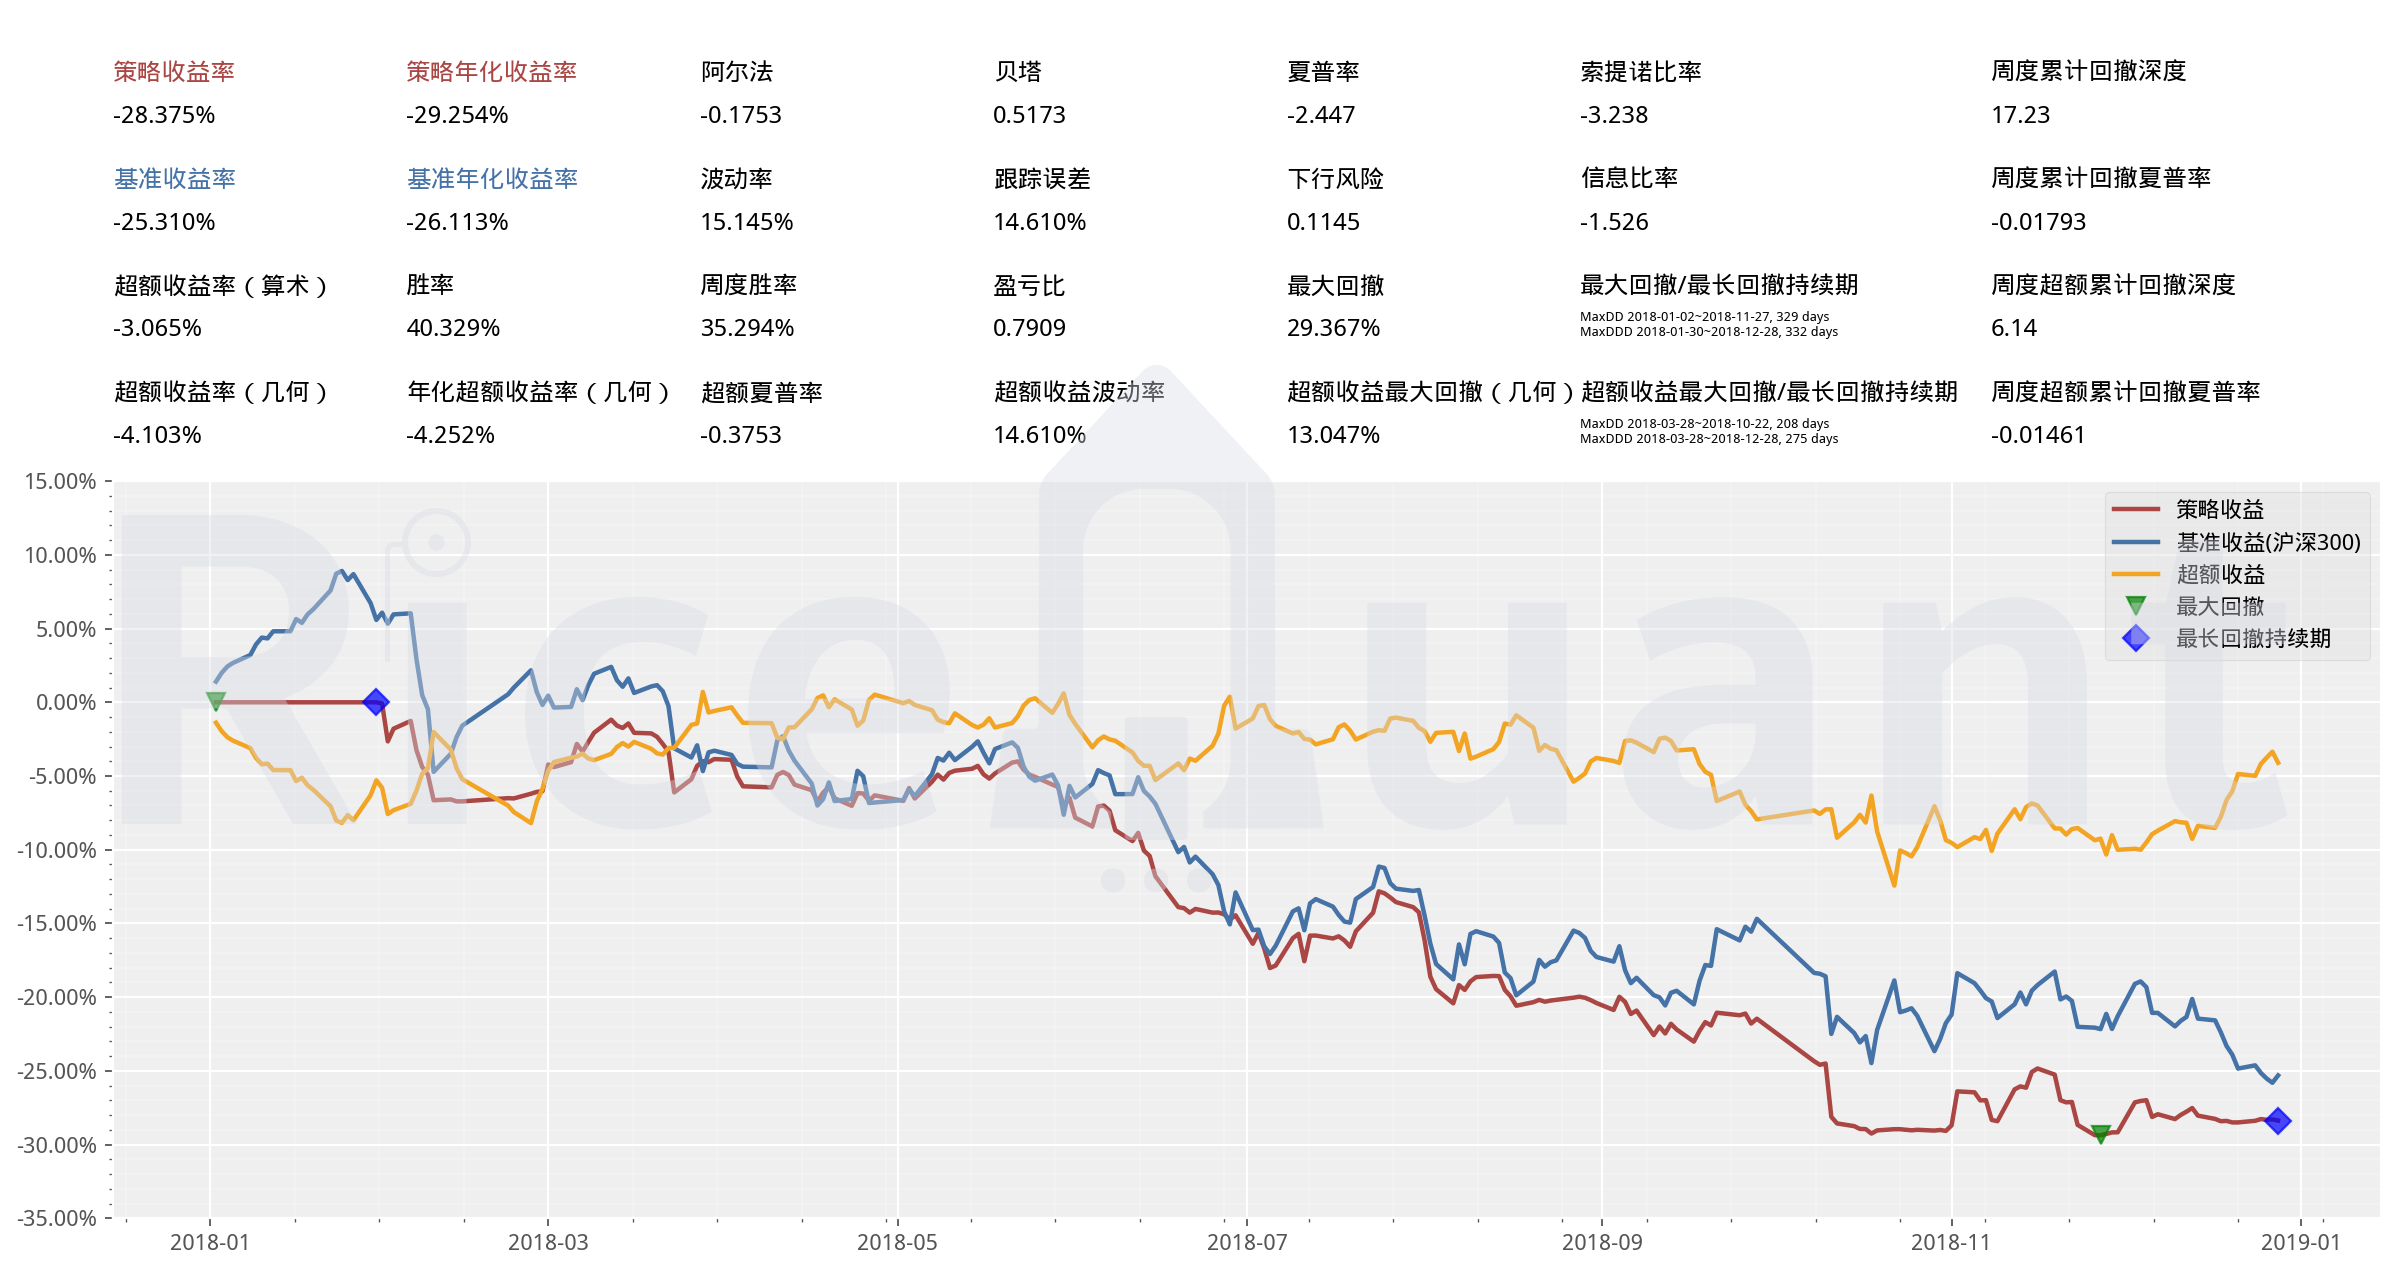

MultiOLS_rf在2018


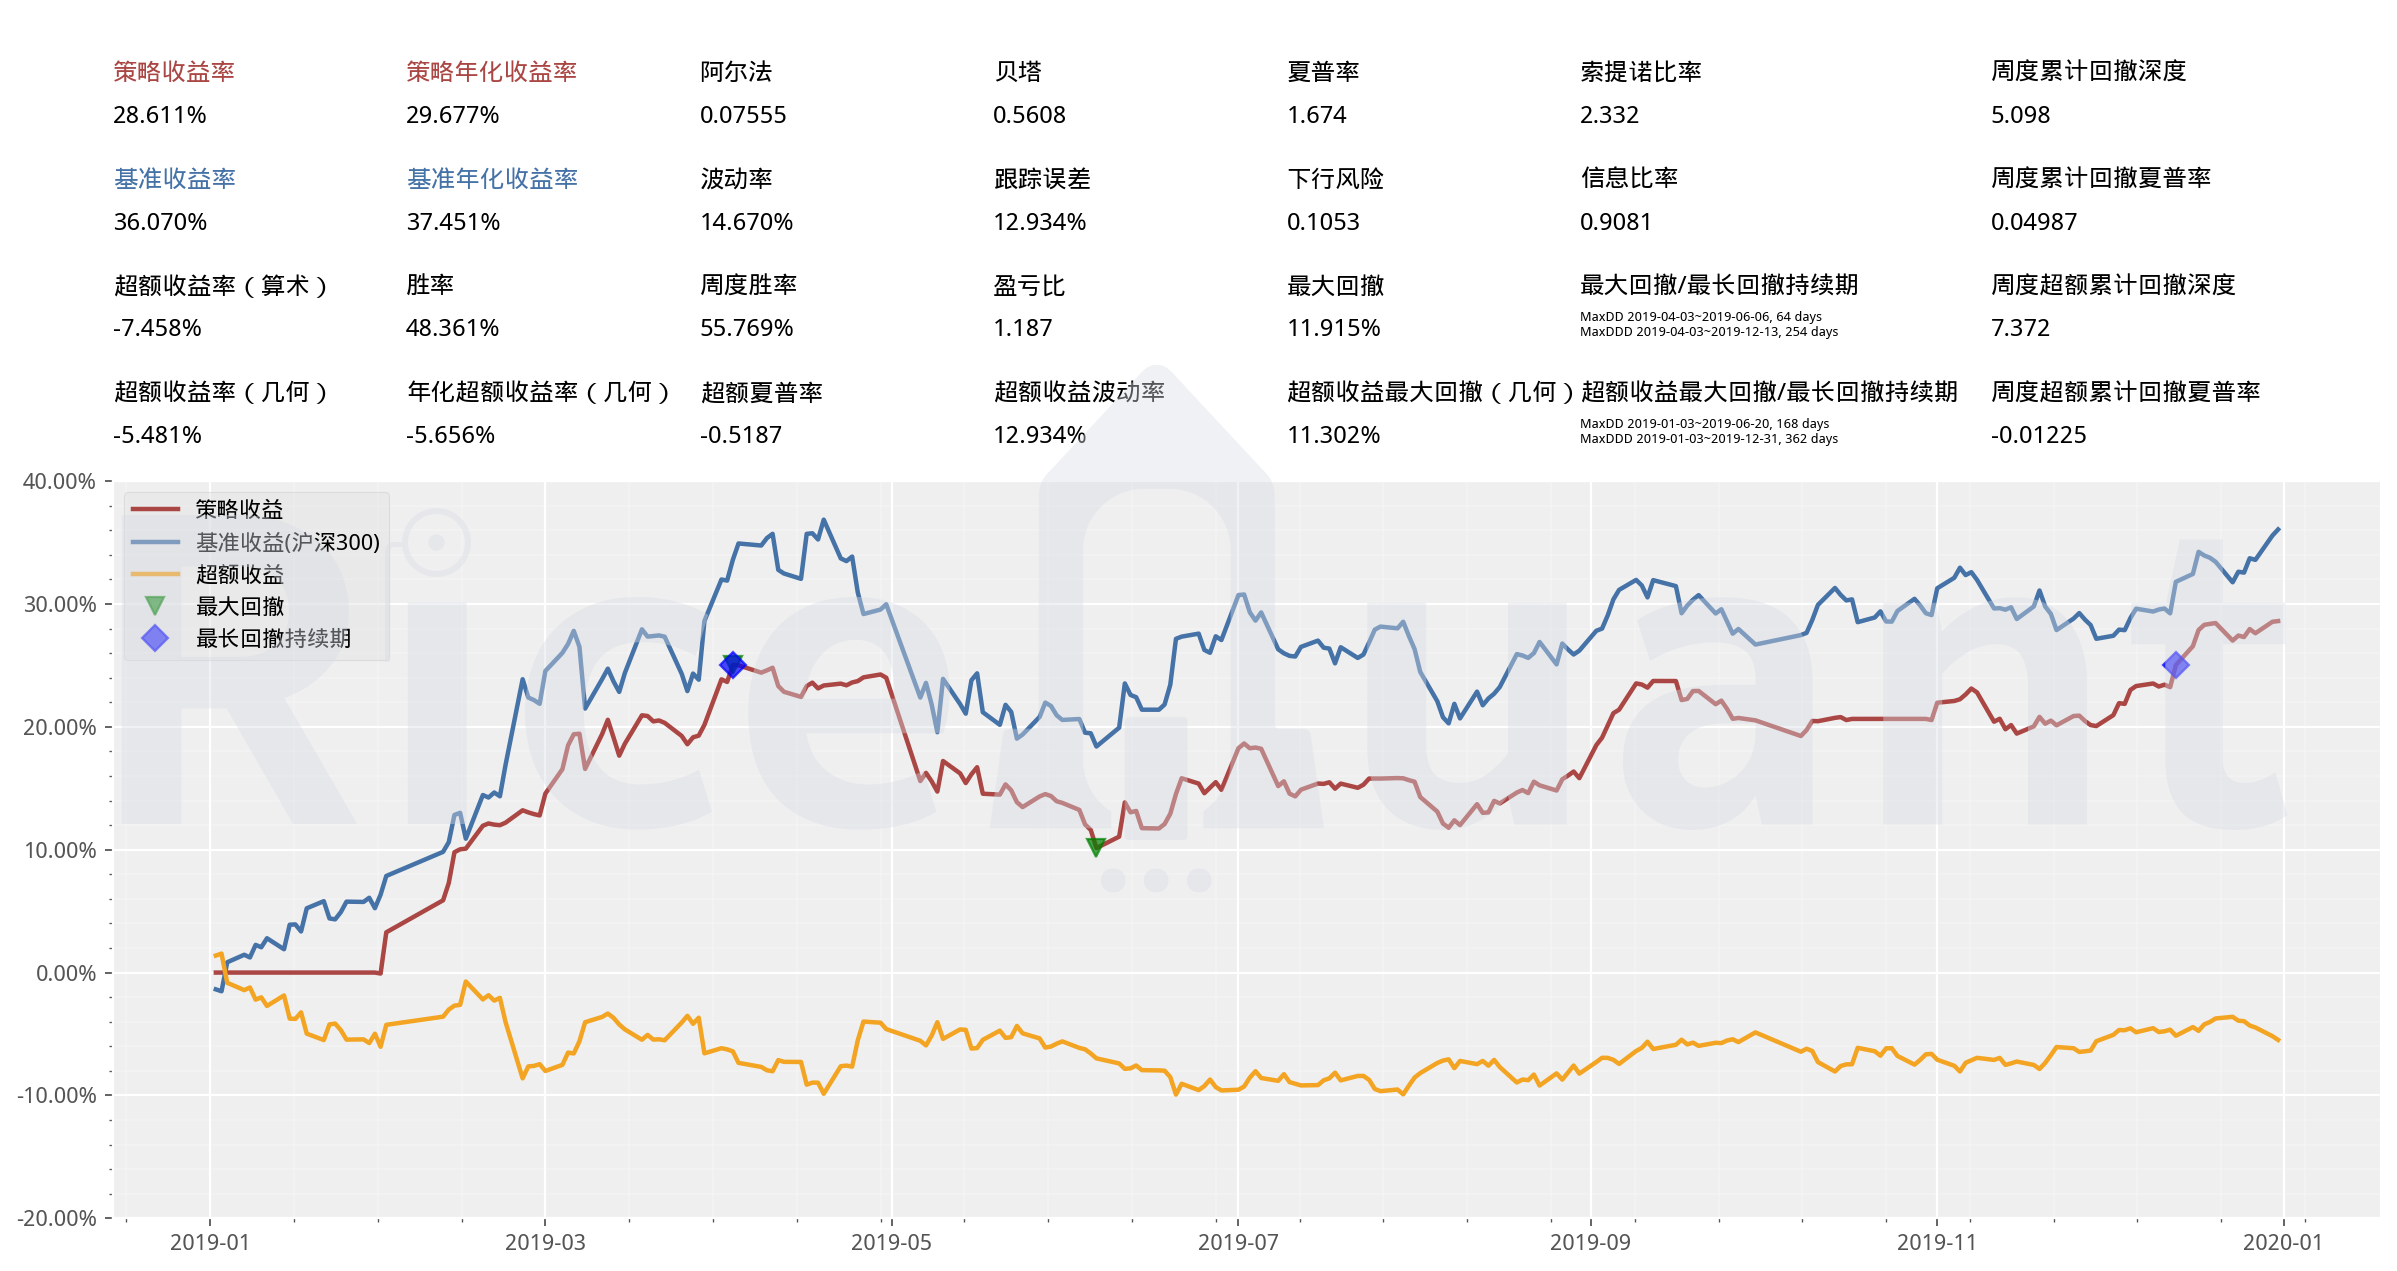

MultiOLS_rf在2019


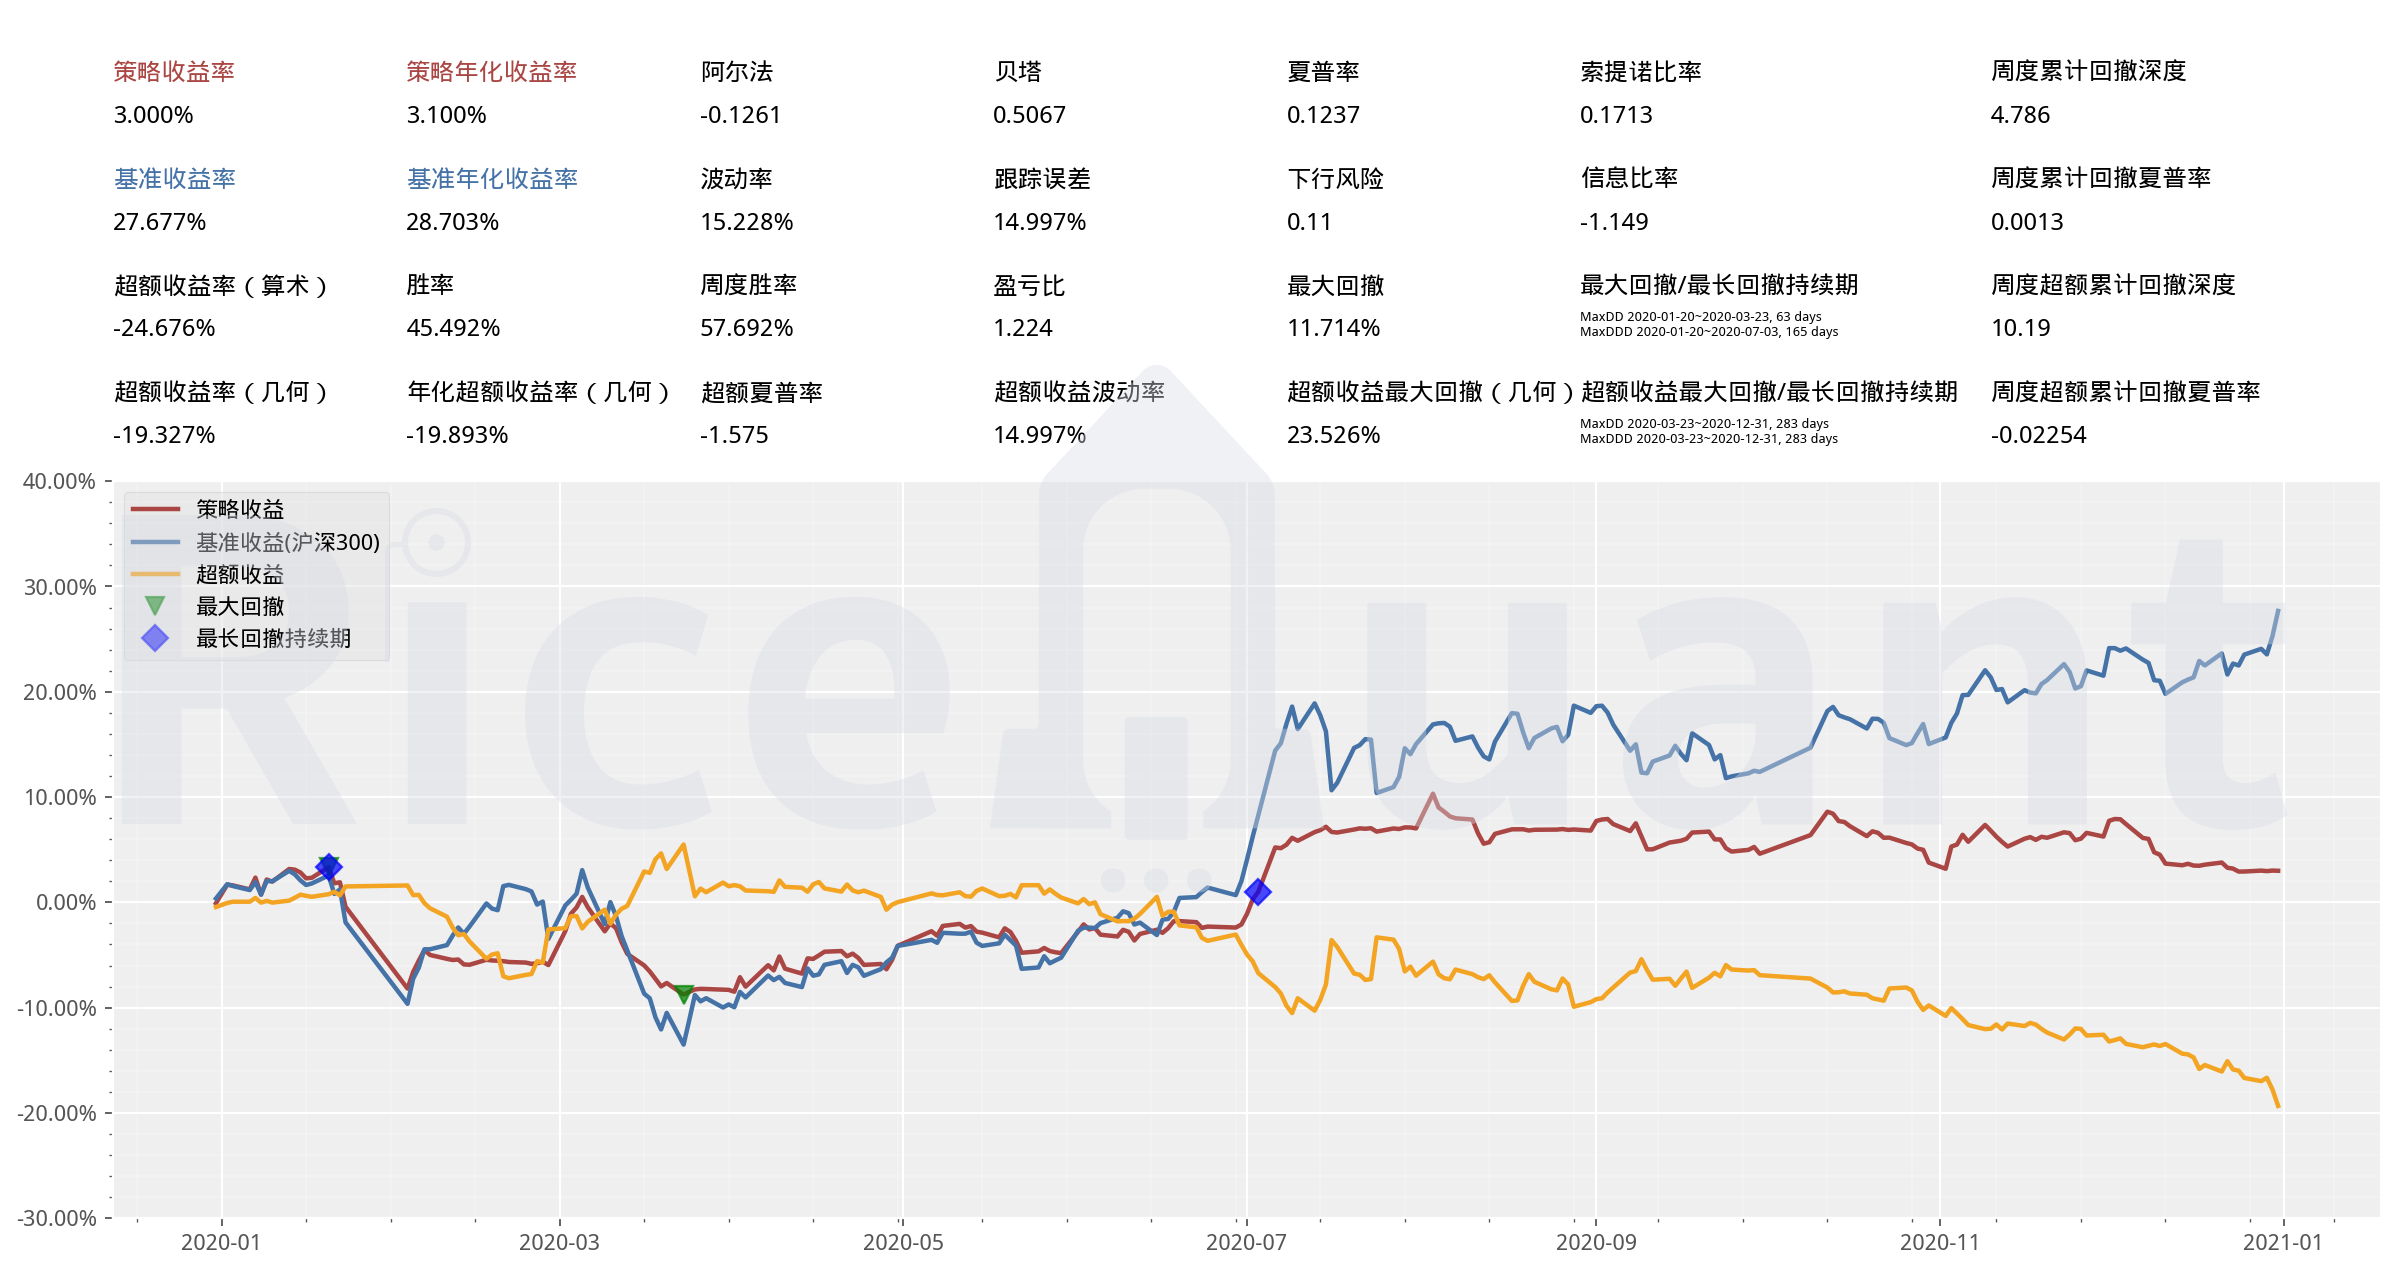

MultiOLS_rf在2020


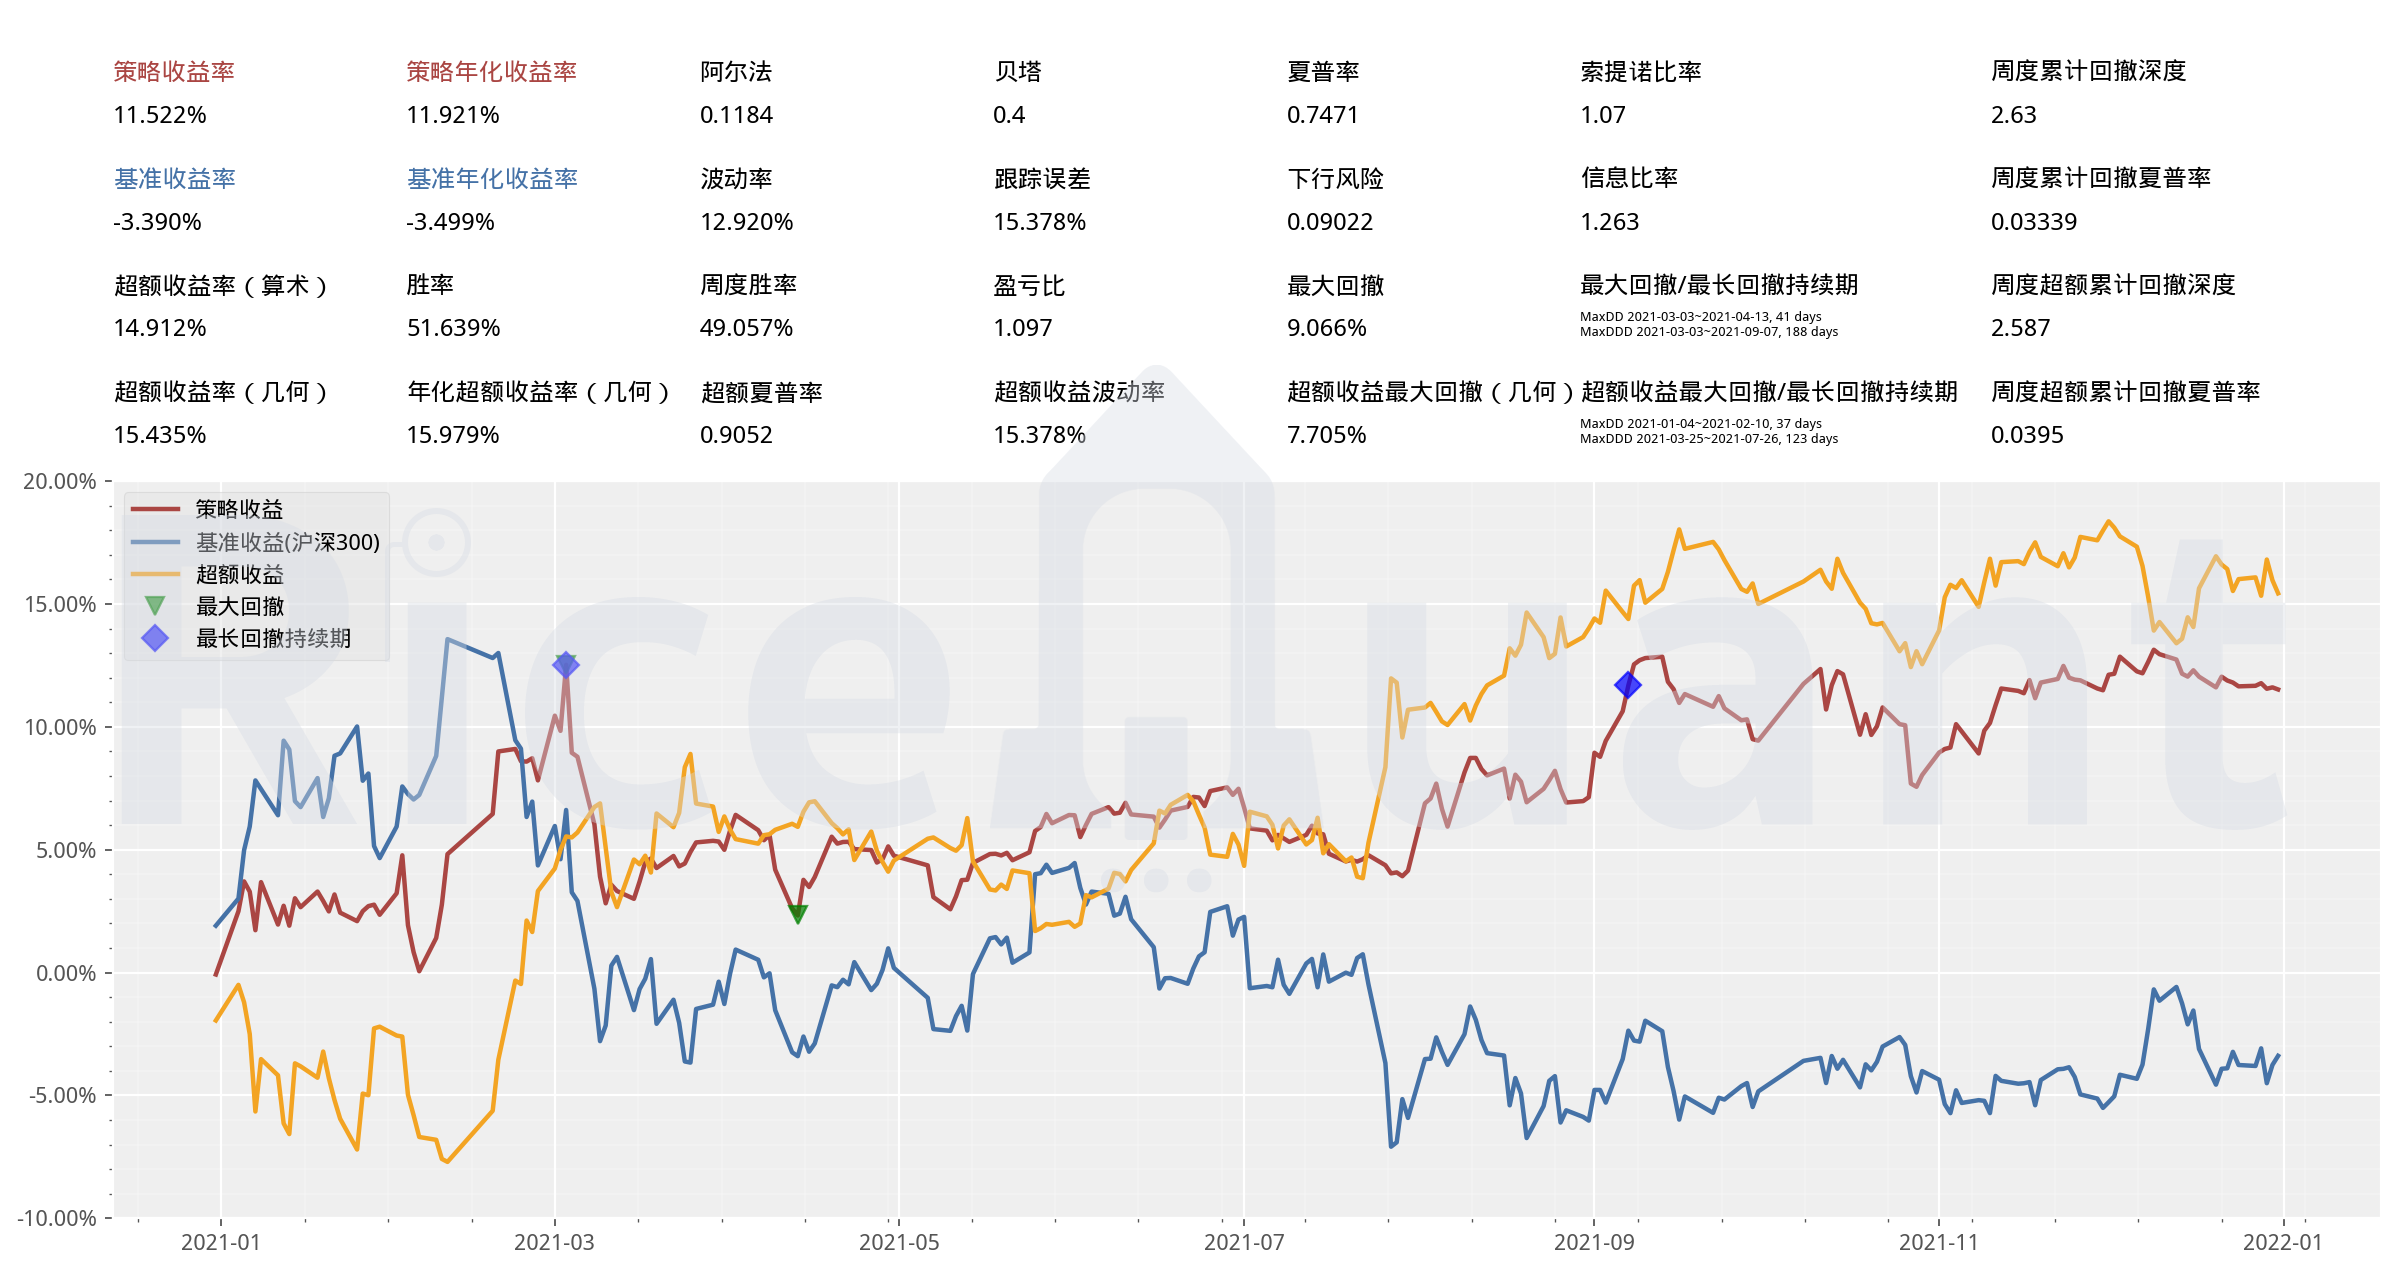

MultiOLS_rf在2021


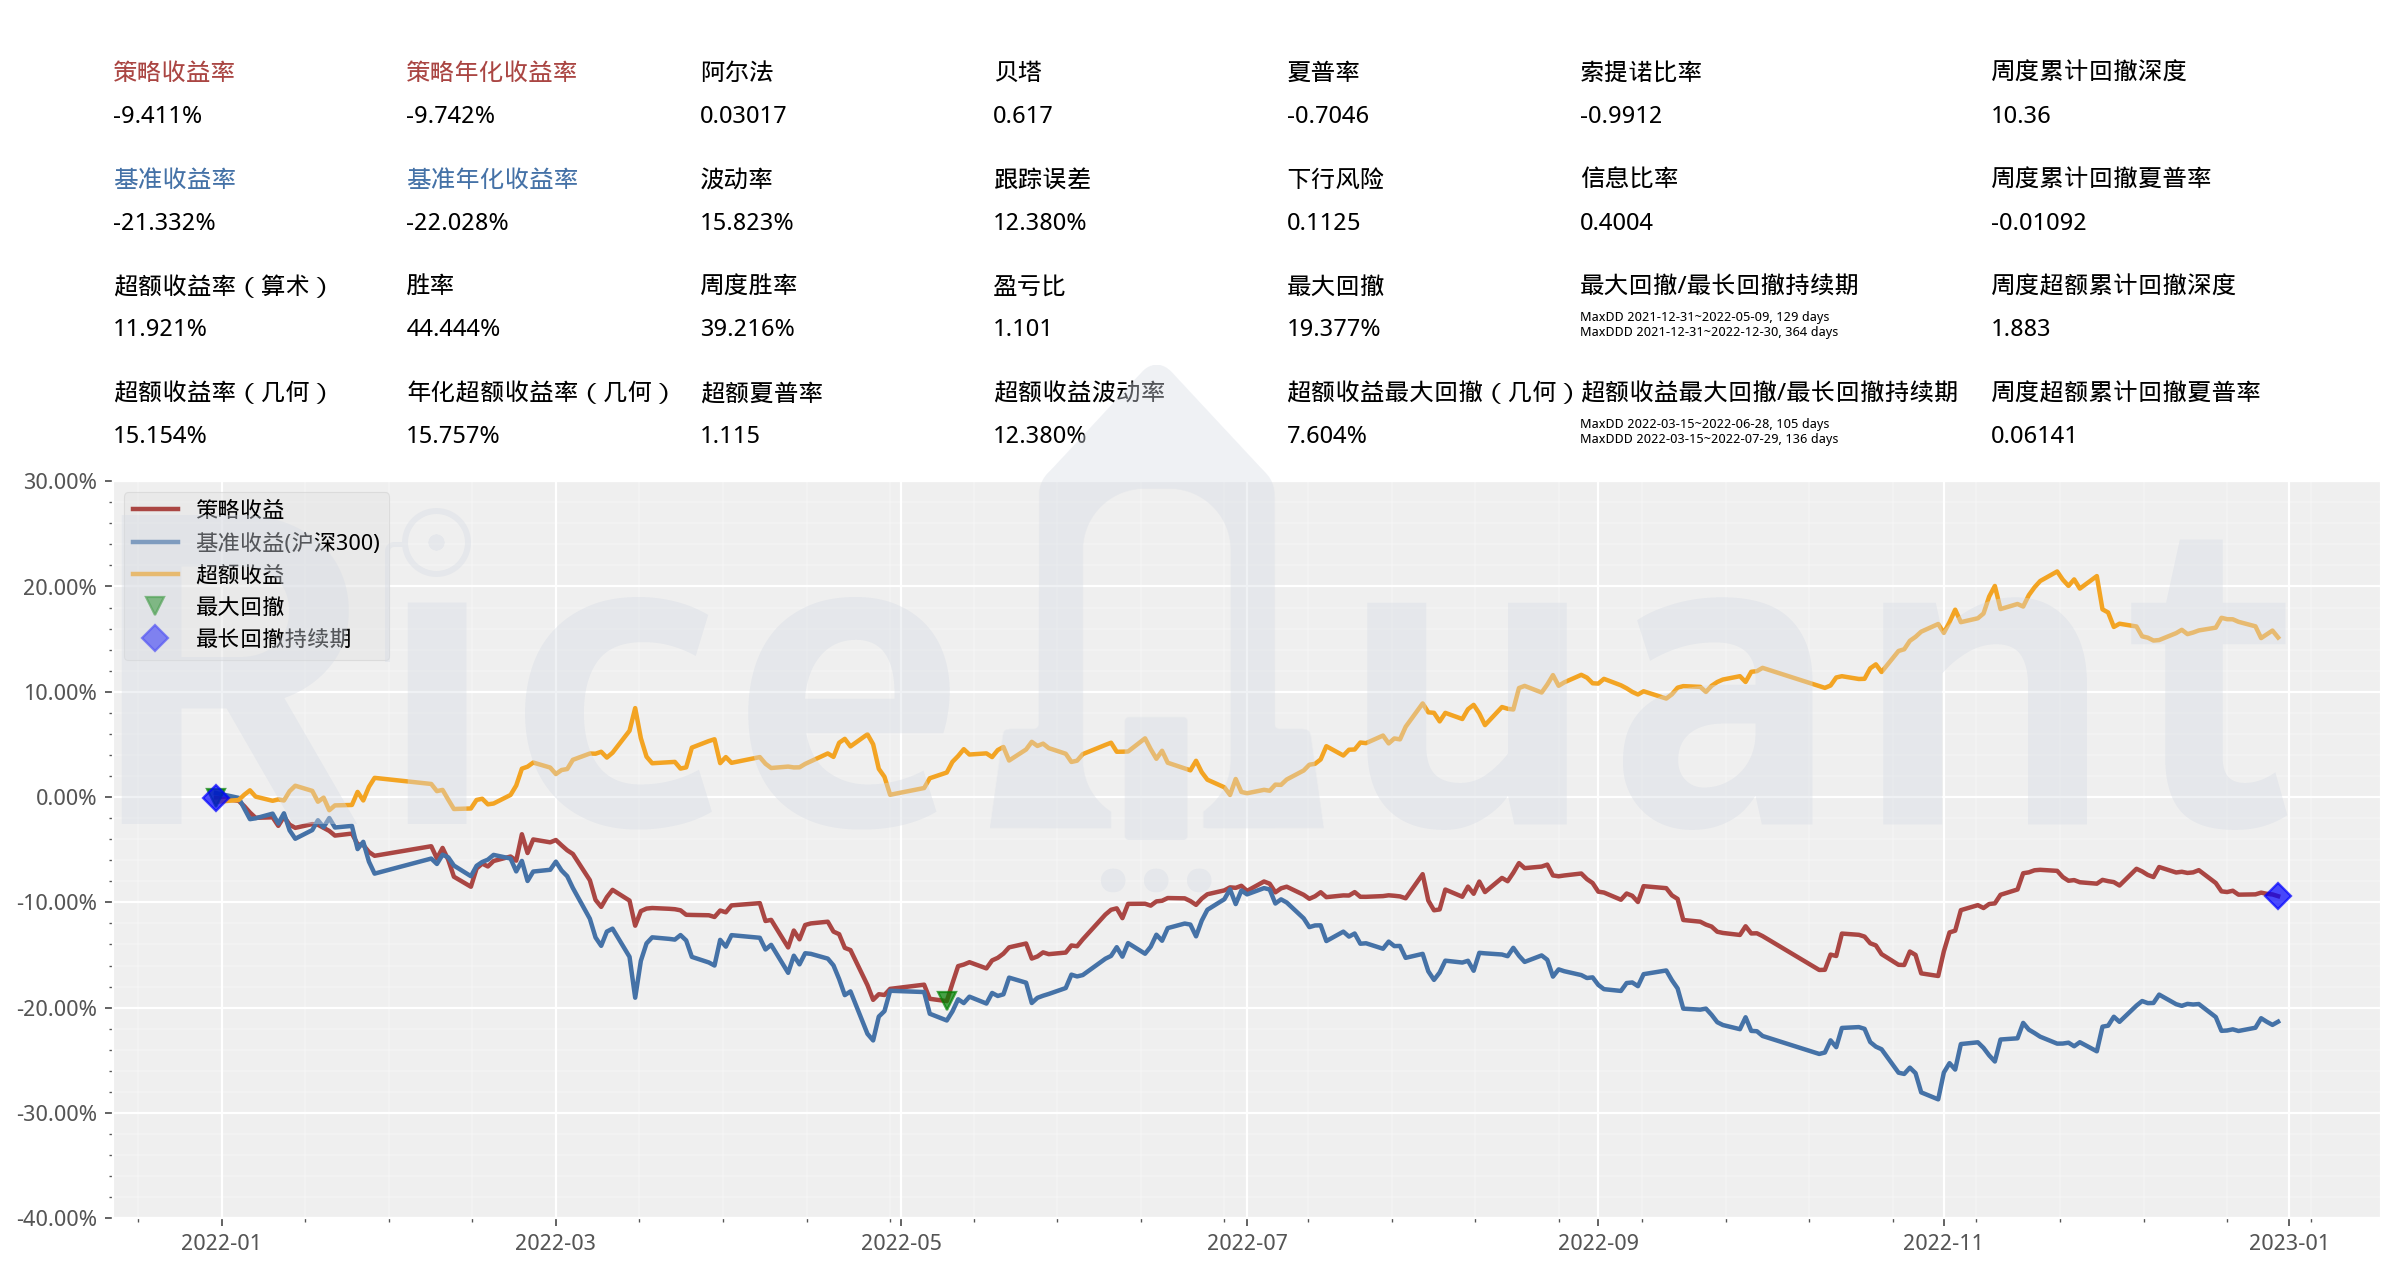

MultiOLS_rf在2022


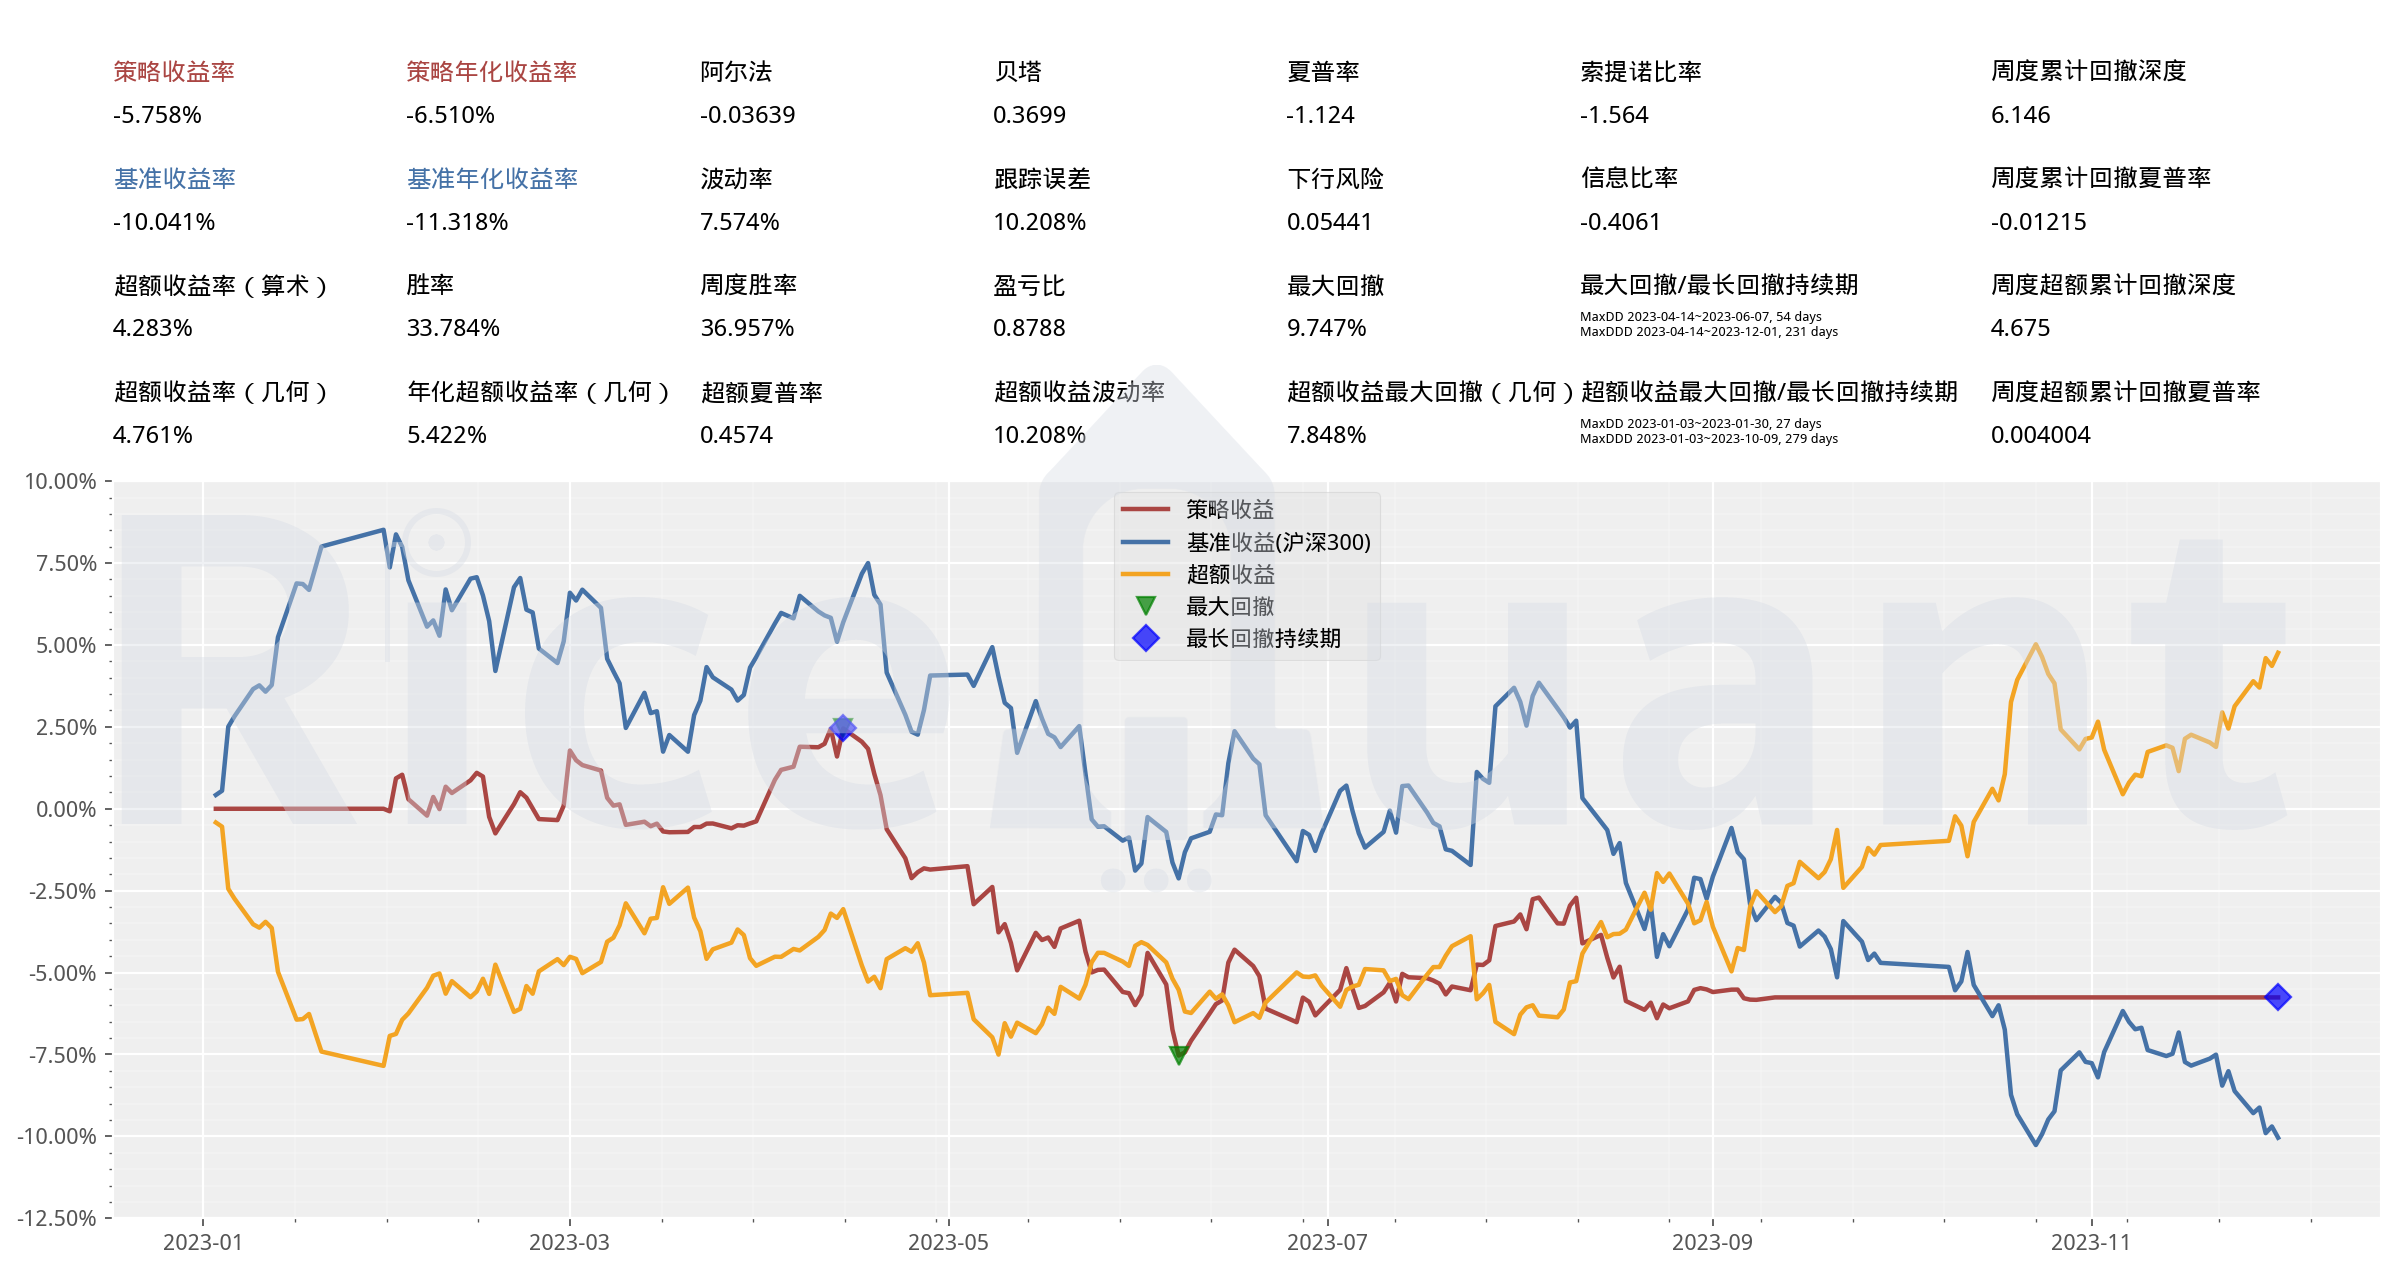

In [6]:
#读取多因子选出的股票
MultiOLS_XGBoost = pd.read_csv("MultiOLS_xgboost.csv",index_col = 0)
MultiOLS_rf = pd.read_csv("MultiOLS_rf.csv",index_col = 0)

Factor_dfs = [MultiOLS_XGBoost,MultiOLS_rf]
Factor_df_names = ['MultiOLS_XGBoost','MultiOLS_rf']
#分年回测
back_test_details = pd.DataFrame()
year_list = pd.date_range(start = '20150101', end = '20240101', freq = '1Y')
for df,name in zip(Factor_dfs,Factor_df_names):
    data = df
    df_name = name
    for year_idx in range(len(year_list) - 1):
        start_date = str(year_list[year_idx])[:10]
        end_date = str(year_list[year_idx + 1])[:10]
        year = start_date[:4]
        print(f"{df_name}在{year}")
        # 初始资金
        init_cash = 1000000
        # 基准
        benchmark = '000300.XSHG'
        # 手续费(%)
        commission = 0
        min_commission = 0
        tax = 0
        # 读取持仓数据和名称
        data = df
        df_name = name
        # 改变日期格式
        data.index = pd.to_datetime(data.index.tolist())
        # 判断买入条件的天数
        days = 22
        # 得分上限
        max_score = 3
        # 止盈/止损阀值
        win_threshold = 0.20
        loss_threshold = 0.15
        # 回测
        config = {"base": {"accounts": {"STOCK": init_cash}, "start_date": start_date, "end_date": end_date, "frequency": "1d"},
                  "mod": {"sys_analyser": {"plot": True, "benchmark": benchmark},
                          "sys_transaction_cost": {"stock_commission_multiplier ": commission, "tax_multiplier": tax, "cn_stock_min_commission": min_commission}},
                  "extra": {"log_level": "error"}}
        result = run_func(init=init, before_trading=before_trading, handle_bar=handle_bar, after_trading=after_trading, config=config)
        #获取回测结果详细分析
        result_analysis = result['sys_analyser']
        #获取交易历史记录
        trade_records = result_analysis['trades']
        trade_records.to_csv(f"{df_name}_trade_records_{year}.csv")
        #获取portfolio
        portfolio = result_analysis['portfolio']
        benchmark = result_analysis['benchmark_portfolio']
        concat_port_ben = pd.concat([portfolio,benchmark],axis = 1)
        concat_port_ben.to_csv(f'{df_name}_portfolio_records_{year}.csv')
        #获取summray并合并进back_test_details
        summary = pd.DataFrame(result_analysis['summary']).iloc[0].to_frame().rename(columns = {0:f"{df_name}_{year}"})
        back_test_details = pd.concat([back_test_details,summary],axis = 1)
    back_test_details.to_csv(f"{df_name}分年回测summary.csv")

In [ ]:
#读取多因子选出的股票
GAM = pd.read_csv('Stock_candidate_GAM.csv',index_col = 0)
XGBoost = pd.read_csv('Stock_candidate_XGBoost.csv', index_col = 0)
RandomForest = pd.read_csv('Stock_candidate_RandomForest.csv', index_col=0)

MultiOLS = pd.read_csv('MultiOLS.csv',index_col = 0)
MultiOLS_All = pd.read_csv('MultiOLS_All.csv',index_col = 0)

LSTM = pd.read_csv('Stock_candidate_LSTM.csv',index_col = 0)
DNN = pd.read_csv('Stock_candidate_DNN.csv',index_col = 0)


Factor_dfs = [GAM,XGBoost,RandomForest,MultiOLS,MultiOLS_All,LSTM,DNN]
Factor_df_names = ['GAM','XGBoost','RandomForest','MultiOLS','MultiOLS_All','LSTM','DNN']
#批量回测
back_test_details = pd.DataFrame()
print('GAM')
for df,name in zip(Factor_dfs,Factor_df_names):
    print(name)
    start_date = '2015-02-15'
    end_date = '2023-08-01'
    # 初始资金
    init_cash = 1000000
    # 基准
    benchmark = '000300.XSHG'
    # 手续费(%)
    commission = 0
    min_commission = 0
    tax = 0
    # 读取持仓数据和名称
    data = df
    df_name = name
    # 改变日期格式
    data.index = pd.to_datetime(data.index.tolist())
    # 判断买入条件的天数
    days = 22
    # 得分上限
    max_score = 3
    # 止盈/止损阀值
    win_threshold = 0.20
    loss_threshold = 0.15
    # 回测
    config = {"base": {"accounts": {"STOCK": init_cash}, "start_date": start_date, "end_date": end_date, "frequency": "1d"},
              "mod": {"sys_analyser": {"plot": True, "benchmark": benchmark},
                      "sys_transaction_cost": {"stock_commission_multiplier ": commission, "tax_multiplier": tax, "cn_stock_min_commission": min_commission}},
              "extra": {"log_level": "error"}}
    result = run_func(init=init, before_trading=before_trading, handle_bar=handle_bar, after_trading=after_trading, config=config)
    #获取回测结果详细分析
    result_analysis = result['sys_analyser']
    #获取交易历史记录
    trade_records = result_analysis['trades']
    trade_records.to_csv(f"{df_name}_trade_records.csv")
    #获取portfolio
    portfolio = result_analysis['portfolio'].loc['2015-03-30':]
    benchmark = result_analysis['benchmark_portfolio'].loc['2015-03-30':]
    concat_port_ben = pd.concat([portfolio,benchmark],axis = 1)
    concat_port_ben.to_csv(f'{df_name}_portfolio_records.csv')
    #获取summray并合并进back_test_details
    summary = pd.DataFrame(result_analysis['summary']).iloc[0].to_frame().rename(columns = {0:df_name})
    back_test_details = pd.concat([back_test_details,summary],axis = 1)
back_test_details.to_csv("策略全年回测.csv")

In [ ]:
#读取多因子选出的股票
GAM = pd.read_csv('Stock_candidate_GAM.csv',index_col = 0)
XGBoost = pd.read_csv('Stock_candidate_XGBoost.csv', index_col = 0)
RandomForest = pd.read_csv('Stock_candidate_RandomForest.csv', index_col=0)
MultiOLS = pd.read_csv('MultiOLS.csv',index_col = 0)
MultiOLS_All = pd.read_csv('MultiOLS_All.csv',index_col = 0)
LSTM = pd.read_csv('Stock_candidate_LSTM.csv',index_col = 0)
Factor_dfs = [GAM,XGBoost,RandomForest,MultiOLS,MultiOLS_All]
Factor_df_names = ['GAM','XGBoost','RandomForest','MultiOLS','MultiOLS_All']
#分年回测
back_test_details = pd.DataFrame()
year_list = pd.date_range(start = '20150101', end = '20240101', freq = '1Y')
for df,name in zip(Factor_dfs,Factor_df_names):
    data = df
    df_name = name
    for year_idx in range(len(year_list) - 1):
        start_date = str(year_list[year_idx])[:10]
        end_date = str(year_list[year_idx + 1])[:10]
        year = start_date[:4]
        print(f"{df_name}在{year}")
        # 初始资金
        init_cash = 1000000
        # 基准
        benchmark = '000300.XSHG'
        # 手续费(%)
        commission = 0
        min_commission = 0
        tax = 0
        # 读取持仓数据和名称
        data = df
        df_name = name
        # 改变日期格式
        data.index = pd.to_datetime(data.index.tolist())
        # 判断买入条件的天数
        days = 22
        # 得分上限
        max_score = 3
        # 止盈/止损阀值
        win_threshold = 0.20
        loss_threshold = 0.15
        # 回测
        config = {"base": {"accounts": {"STOCK": init_cash}, "start_date": start_date, "end_date": end_date, "frequency": "1d"},
                  "mod": {"sys_analyser": {"plot": True, "benchmark": benchmark},
                          "sys_transaction_cost": {"stock_commission_multiplier ": commission, "tax_multiplier": tax, "cn_stock_min_commission": min_commission}},
                  "extra": {"log_level": "error"}}
        result = run_func(init=init, before_trading=before_trading, handle_bar=handle_bar, after_trading=after_trading, config=config)
        #获取回测结果详细分析
        result_analysis = result['sys_analyser']
        #获取交易历史记录
        trade_records = result_analysis['trades']
        trade_records.to_csv(f"{df_name}_trade_records_{year}.csv")
        #获取portfolio
        portfolio = result_analysis['portfolio']
        benchmark = result_analysis['benchmark_portfolio']
        concat_port_ben = pd.concat([portfolio,benchmark],axis = 1)
        concat_port_ben.to_csv(f'{df_name}_portfolio_records_{year}.csv')
        #获取summray并合并进back_test_details
        summary = pd.DataFrame(result_analysis['summary']).iloc[0].to_frame().rename(columns = {0:f"{df_name}_{year}"})
        back_test_details = pd.concat([back_test_details,summary],axis = 1)
    back_test_details.to_csv(f"{df_name}分年回测summary.csv")